## Module 1 : Exploration, Nettoyage et Analyse des données

### Importation des librairies.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\khoul\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khoul\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "C:\Users\khoul\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

### Importation du dataset.

In [ ]:
df = pd.read_csv('./data/dataset_ProjetML_2026.csv');
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Description du dataset.

In [ ]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [ ]:
print('=== INFO ===')
df.info()
print('\n=== DESCRIBE ===')
df.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB

=== DESCRIBE ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Les valeurs nulls dans chaque colonne du dataset.

In [ ]:
df.isnull().sum()

Poids               1029
Volume               540
Conductivite        1017
Opacite             1035
Rigidite             558
Prix_Revente         536
Categorie            514
Source               536
Rapport_Collecte       0
dtype: int64

In [ ]:
df.Categorie

0           Papier
1        Plastique
2            Verre
3           Papier
4           Papier
           ...    
10495        Verre
10496        Verre
10497       Papier
10498    Plastique
10499        Verre
Name: Categorie, Length: 10500, dtype: object

In [ ]:
### Liste des categories

In [ ]:
df.Categorie.unique()

array(['Papier', 'Plastique', 'Verre', 'Métal', nan], dtype=object)

In [ ]:
df.Categorie.value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [ ]:
### liste des sources

In [ ]:
df.Source.unique()

array([nan, 'Usine_A', 'Usine_B', 'Centre_Tri', 'Collecte_Citoyenne'],
      dtype=object)

In [ ]:
df.Source.value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

In [ ]:
### DISTRIBUTION DE LA CIBLE naraw kol categorie 9adeh fiha bech naarefo dataset equilibre ou non

=== DISTRIBUTION DE LA CIBLE ===
Categorie
Plastique    0.279892
Verre        0.258963
Papier       0.232125
Métal        0.229021
Name: proportion, dtype: float64


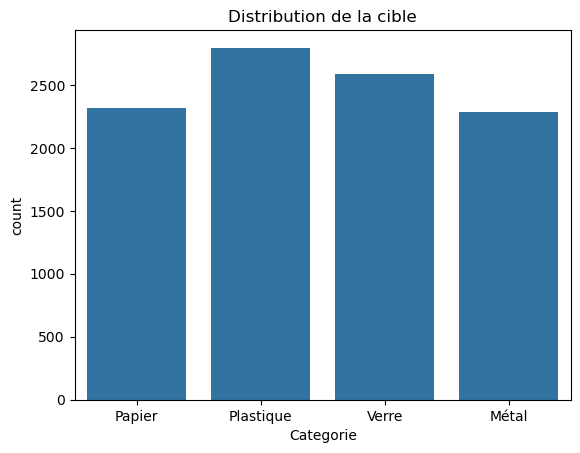

In [ ]:
print('=== DISTRIBUTION DE LA CIBLE ===')
print(df['Categorie'].value_counts(normalize=True))
sns.countplot(x='Categorie', data=df)
plt.title('Distribution de la cible')
plt.show()

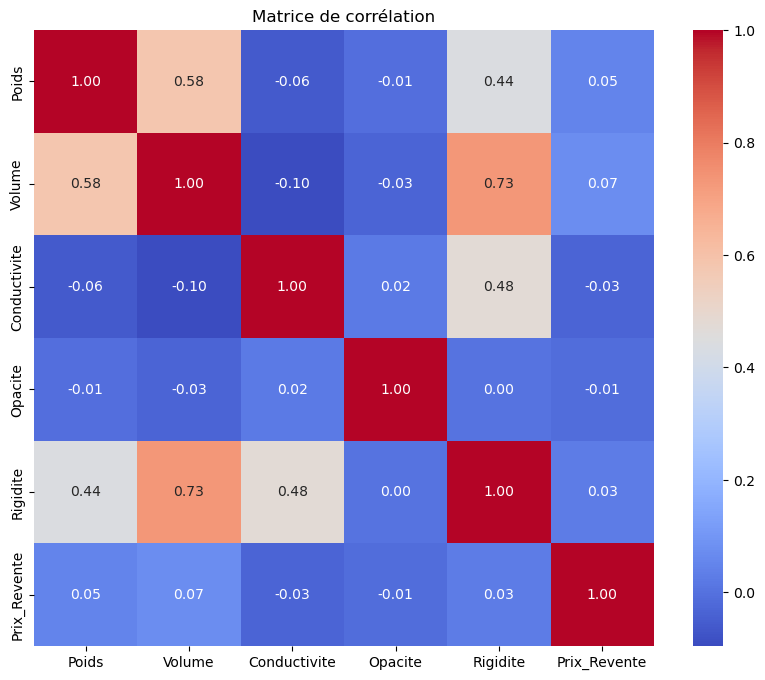

In [ ]:
# Matrice de corrélation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

### Gérer les valeurs manquantes 

In [ ]:
### Total NAn numeriques +  Conserver une copie du dataframe original avec NaN pour les tests

In [ ]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error


colonnes_numeriques = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
colonnes_categorielles = ['Categorie', 'Source']

df_original = df.copy()

print(f'\nTotal NaN numériques : {df[colonnes_numeriques].isnull().sum().sum()}')


Total NaN numériques : 4715


#### Méthode 1 — Imputation par la Médiane

In [ ]:
df_median = df_original.copy()

imputer_median = SimpleImputer(strategy='median')
df_median[colonnes_numeriques] = imputer_median.fit_transform(df_median[colonnes_numeriques])

# Imputation mode pour les colonnes catégorielles
for col in colonnes_categorielles:
    if df_median[col].isna().any():
        df_median[col] = df_median[col].fillna(df_median[col].mode()[0])

print('=== Après imputation Médiane ===')
print('NaN restants :', df_median[colonnes_numeriques].isnull().sum().sum())
df_median[colonnes_numeriques].describe()

=== Après imputation Médiane ===
NaN restants : 0


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,74.013361,141.511423,0.187560,1.100565,5.839524,55.808186
std,121.962083,133.411893,0.365314,5.218099,3.010642,701.540297
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,21.593823,45.901957,0.000000,0.234916,3.000000,1.710014
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,83.566834,186.002230,0.000000,1.000000,9.000000,6.413580
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


#### Méthode 2 — KNN Imputer (k=5)

In [ ]:
df_knn = df_original.copy()

imputer_knn = KNNImputer(n_neighbors=5)
df_knn[colonnes_numeriques] = imputer_knn.fit_transform(df_knn[colonnes_numeriques])

for col in colonnes_categorielles:
    if df_knn[col].isna().any():
        df_knn[col] = df_knn[col].fillna(df_knn[col].mode()[0])

print('=== Après imputation KNN (k=5) ===')
print('NaN restants :', df_knn[colonnes_numeriques].isnull().sum().sum())
df_knn[colonnes_numeriques].describe()

=== Après imputation KNN (k=5) ===
NaN restants : 0


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,79.564142,144.165313,0.207351,1.178266,5.890971,56.110683
std,128.635863,135.951792,0.376787,5.474912,3.090306,701.790933
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.983800,44.428747,0.000000,0.197534,3.000000,1.455536
50%,40.062928,87.805300,0.000000,0.553484,5.000000,4.128598
75%,129.456438,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


#### Méthode 3 — IterativeImputer (MICE)

In [ ]:
df_iterative = df_original.copy()

imputer_iterative = IterativeImputer(max_iter=10, random_state=42)
df_iterative[colonnes_numeriques] = imputer_iterative.fit_transform(df_iterative[colonnes_numeriques])

for col in colonnes_categorielles:
    if df_iterative[col].isna().any():
        df_iterative[col] = df_iterative[col].fillna(df_iterative[col].mode()[0])

print('=== Après imputation IterativeImputer (MICE) ===')
print('NaN restants :', df_iterative[colonnes_numeriques].isnull().sum().sum())
df_iterative[colonnes_numeriques].describe()

=== Après imputation IterativeImputer (MICE) ===
NaN restants : 0


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000,10500.000000
mean,77.092358,144.388659,0.205602,1.161254,5.890029,58.419490
std,123.249815,135.468726,0.369759,5.215185,3.072290,701.519219
min,-99.000000,-44.469801,-0.349146,0.000037,1.000000,-50.000000
25%,19.826663,44.863175,0.000000,0.234916,3.000000,1.710014
50%,39.874930,89.436539,0.000000,1.000000,5.000000,4.356633
75%,128.437473,240.200023,0.206850,1.000000,9.000000,11.131781
max,2334.218831,620.111549,1.019897,55.000000,11.337496,9999.000000


#### Comparaison des 3 méthodes

In [ ]:
# ── Comparaison des statistiques descriptives (mean, std, median) ───

In [ ]:
methodes = {
    'Médiane': df_median,
    'KNN (k=5)': df_knn,
    'IterativeImputer': df_iterative
}
stats_list = []
for nom, df_imp in methodes.items():
    stats = df_imp[colonnes_numeriques].agg(['mean', 'std', 'median'])
    stats.index = [f'{nom}_{s}' for s in stats.index]
    stats_list.append(stats)

stats_comparaison = pd.concat(stats_list)
print('=== Statistiques descriptives par méthode ===')
display(stats_comparaison.round(3))

=== Statistiques descriptives par méthode ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
Médiane_mean,74.013,141.511,0.188,1.101,5.840,55.808
Médiane_std,121.962,133.412,0.365,5.218,3.011,701.540
Médiane_median,39.193,88.084,0.000,0.553,5.000,4.135
KNN (k=5)_mean,79.564,144.165,0.207,1.178,5.891,56.111
KNN (k=5)_std,128.636,135.952,0.377,5.475,3.090,701.791
KNN (k=5)_median,40.063,87.805,0.000,0.553,5.000,4.129
IterativeImputer_mean,77.092,144.389,0.206,1.161,5.890,58.419
IterativeImputer_std,123.250,135.469,0.370,5.215,3.072,701.519
IterativeImputer_median,39.875,89.437,0.000,1.000,5.000,4.357


In [ ]:
# ── Évaluation : simulation MCAR + calcul RMSE ──
# On masque 10% des valeurs connues, on impute, puis on mesure l'erreur

=== RMSE par méthode d'imputation (simulation MCAR 10%) ===
  Médiane              RMSE = 195.1028
  KNN (k=5)            RMSE = 179.3985
  IterativeImputer     RMSE = 187.1699


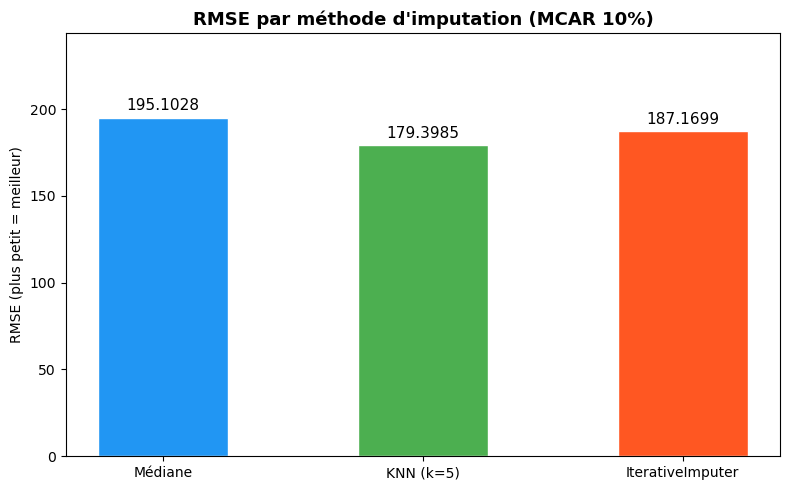

In [ ]:
np.random.seed(42)

# Partir d'un dataframe sans NaN (après une imputation de référence)
df_ref = df_original.copy()
df_ref[colonnes_numeriques] = SimpleImputer(strategy='median').fit_transform(df_ref[colonnes_numeriques])

# Créer un masque MCAR : 10% de valeurs masquées aléatoirement
mask = np.random.random(df_ref[colonnes_numeriques].shape) < 0.10
df_masked = df_ref.copy()
df_masked[colonnes_numeriques] = df_ref[colonnes_numeriques].mask(pd.DataFrame(mask, columns=colonnes_numeriques))

resultats_rmse = {}

# Médiane
imp = SimpleImputer(strategy='median')
imputed = imp.fit_transform(df_masked[colonnes_numeriques])
rmse = np.sqrt(mean_squared_error(df_ref[colonnes_numeriques].values[mask], imputed[mask]))
resultats_rmse['Médiane'] = rmse

# KNN
imp = KNNImputer(n_neighbors=5)
imputed = imp.fit_transform(df_masked[colonnes_numeriques])
rmse = np.sqrt(mean_squared_error(df_ref[colonnes_numeriques].values[mask], imputed[mask]))
resultats_rmse['KNN (k=5)'] = rmse

# IterativeImputer
imp = IterativeImputer(max_iter=10, random_state=42)
imputed = imp.fit_transform(df_masked[colonnes_numeriques])
rmse = np.sqrt(mean_squared_error(df_ref[colonnes_numeriques].values[mask], imputed[mask]))
resultats_rmse['IterativeImputer'] = rmse

# Affichage
print('=== RMSE par méthode d\'imputation (simulation MCAR 10%) ===')
for methode, rmse_val in resultats_rmse.items():
    print(f'  {methode:<20} RMSE = {rmse_val:.4f}')
    # Graphique barres RMSE
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(resultats_rmse.keys(), resultats_rmse.values(), 
              color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', fontsize=11, padding=3)
ax.set_title('RMSE par méthode d\'imputation (MCAR 10%)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (plus petit = meilleur)')
ax.set_ylim(0, max(resultats_rmse.values()) * 1.25)
plt.tight_layout()
plt.show()

In [ ]:
# ── Tableau récapitulatif + choix final ──

In [ ]:
recap = pd.DataFrame({
    'Méthode': ['Médiane', 'KNN (k=5)', 'IterativeImputer (MICE)'],
    'Mécanisme adapté': ['MCAR', 'MCAR / MAR', 'MAR / MNAR'],
    'RMSE (MCAR 10%)': [f"{resultats_rmse['Médiane']:.4f}",
                        f"{resultats_rmse['KNN (k=5)']:.4f}",
                        f"{resultats_rmse['IterativeImputer']:.4f}"]
})
print('=== Tableau comparatif des méthodes d\'imputation ===')
display(recap)

# Sélection de la meilleure méthode selon RMSE
meilleure = min(resultats_rmse, key=resultats_rmse.get)
print(f'\n✅ Méthode retenue : {meilleure} (RMSE le plus faible)')

# Appliquer la meilleure méthode au dataframe principal
if meilleure == 'Médiane':
    df = df_median.copy()
elif meilleure == 'KNN (k=5)':
    df = df_knn.copy()
else:
    df = df_iterative.copy()

print(f'Le dataframe df est maintenant imputé avec la méthode : {meilleure}')
print('NaN restants :', df.isnull().sum().sum())

=== Tableau comparatif des méthodes d'imputation ===


,Méthode,Mécanisme adapté,RMSE (MCAR 10%)
0,Médiane,MCAR,195.1028
1,KNN (k=5),MCAR / MAR,179.3985
2,IterativeImputer (MICE),MAR / MNAR,187.1699



✅ Méthode retenue : KNN (k=5) (RMSE le plus faible)
Le dataframe df est maintenant imputé avec la méthode : KNN (k=5)
NaN restants : 0


In [ ]:
df.isna().sum()

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64

### Traiter les Outliers

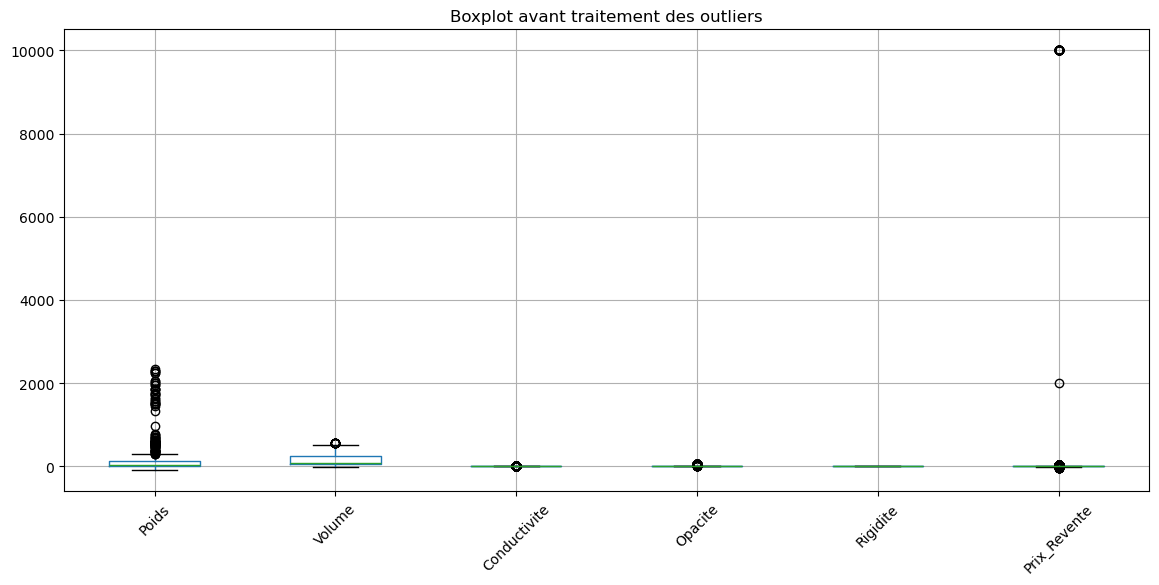

In [ ]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=np.number).boxplot(rot=45)
plt.title('Boxplot avant traitement des outliers')
plt.show()

In [ ]:
### outliers dans la colonne poids

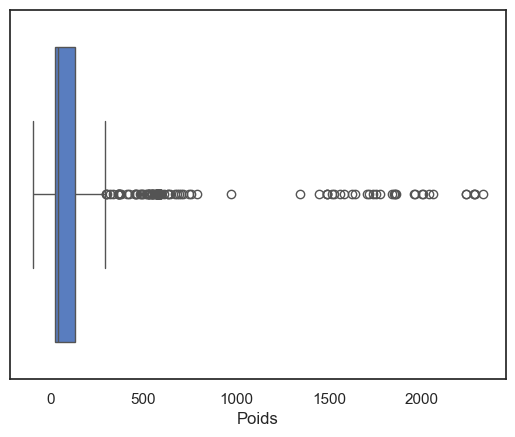

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Poids, orient = 'h')

In [ ]:
Q1 = df.Poids.quantile(0.25)
Q3 = df.Poids.quantile(0.75)
IQR = Q3 - Q1
sup = Q3 + 1.5 * IQR
df.Poids = df.Poids.clip(lower=0, upper=sup)

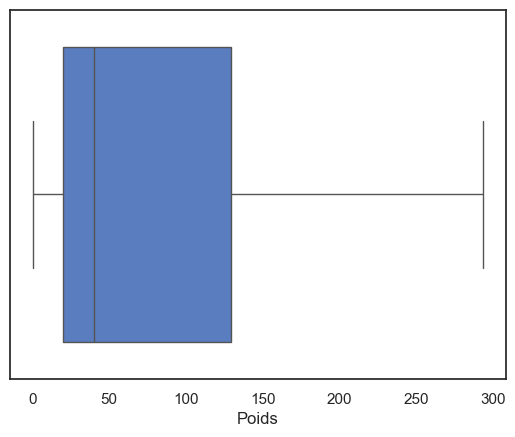

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Poids, orient = 'h')

In [ ]:
df.Poids.head()

0     16.708780
1     47.277476
2    140.393004
3     18.800783
4     13.417848
Name: Poids, dtype: float64

In [ ]:
 ### outliers dans la colonne Volume

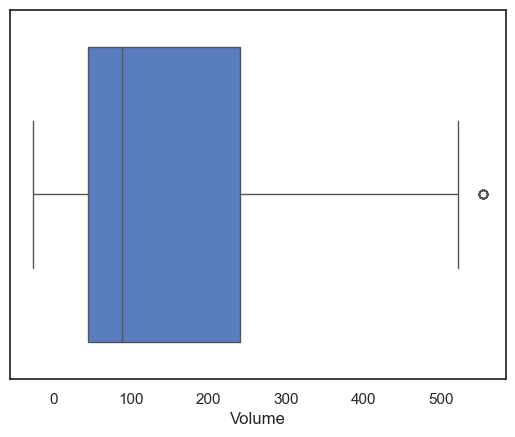

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Volume, orient = 'h')

<Axes: xlabel='Volume'>

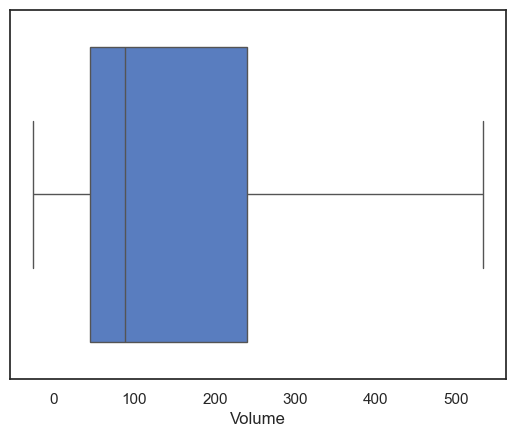

In [ ]:
IQR = df.Volume.quantile(0.75) - df.Volume.quantile(0.25)
Inf = df.Volume.quantile(0.25) - 1.5 * IQR
Sup = df.Volume.quantile(0.75) + 1.5 * IQR

df.Volume = df.Volume.clip(Inf, Sup)

sns.boxplot(data=df.Volume, orient='h')

In [ ]:
 ### outliers dans la colonne Opacite

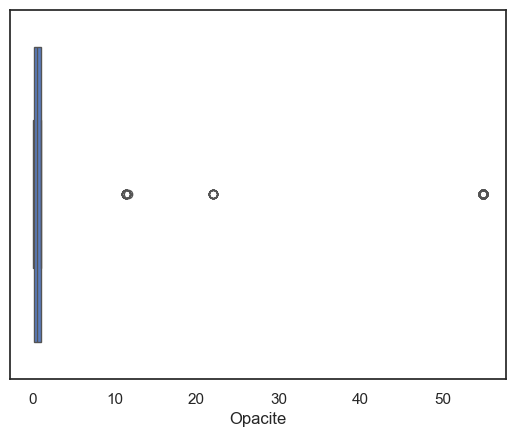

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Opacite, orient = 'h')

In [ ]:
Q1 = df.Opacite.quantile(0.25)
Q3 = df.Opacite.quantile(0.75)
IQR = Q3 - Q1
sup = Q3 + 1.5 * IQR
df.Opacite = df.Opacite.clip(lower=0, upper=sup)

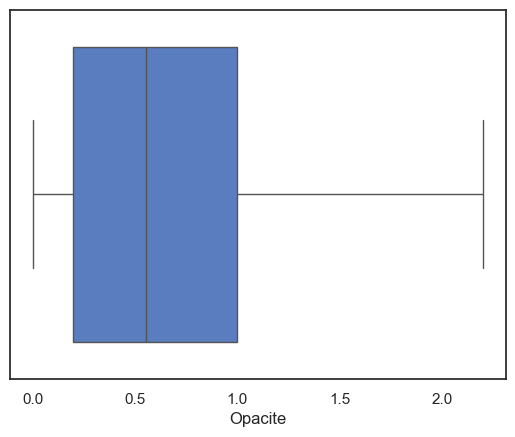

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Opacite, orient = 'h')

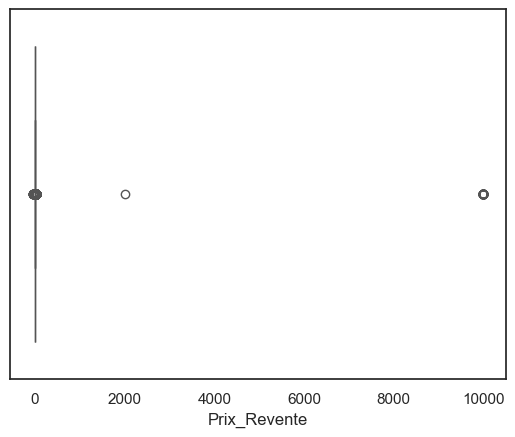

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Prix_Revente, orient = 'h')

In [ ]:
Q1 = df.Prix_Revente.quantile(0.25)
Q3 = df.Prix_Revente.quantile(0.75)
IQR = Q3 - Q1
sup = Q3 + 1.5 * IQR
df.Prix_Revente = df.Prix_Revente.clip(lower=0, upper=sup)

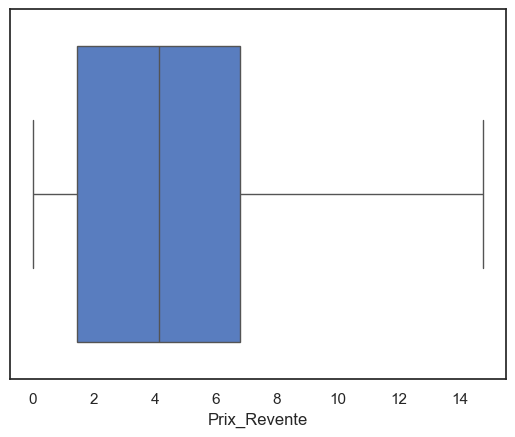

In [ ]:
sns.set(style='white', palette='muted')
ax = sns.boxplot(data = df.Prix_Revente, orient = 'h')

#### Boxplot aprés traitement des outliers

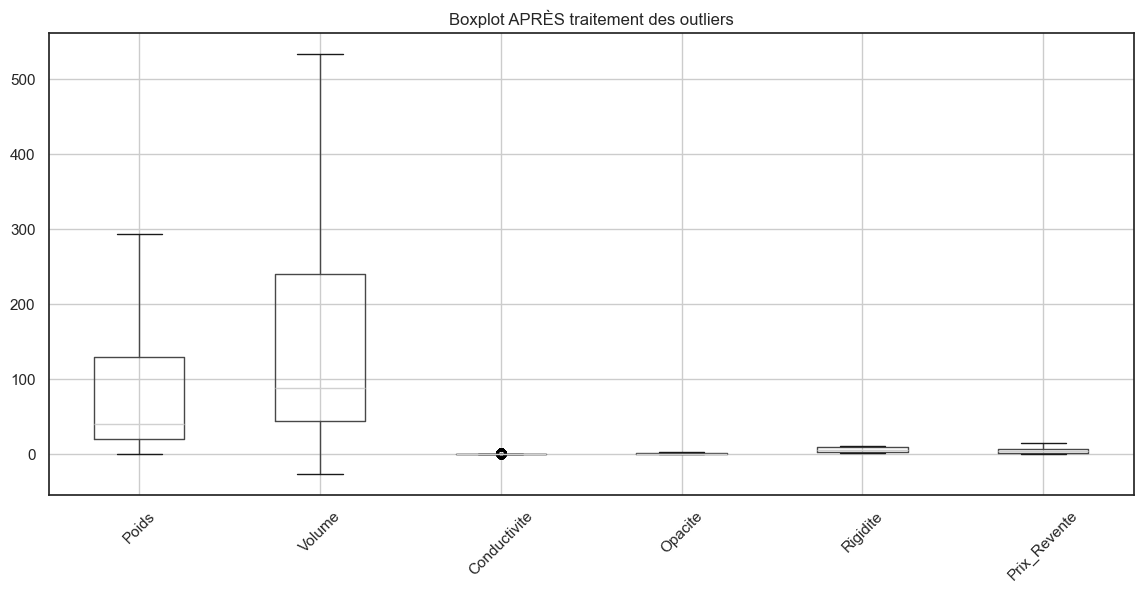

In [ ]:
plt.figure(figsize=(14, 6))
df.select_dtypes(include=np.number).boxplot(rot=45)
plt.title('Boxplot APRÈS traitement des outliers')
plt.show()

### Feature Engineering 

#### Standardiser les variables numériques

In [ ]:
print("--- Standardisation des variables numériques ---")
cols_a_normaliser = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite']

scaler = StandardScaler()
df[cols_a_normaliser] = scaler.fit_transform(df[cols_a_normaliser])

import joblib
joblib.dump(scaler, './data/processed/scaler.pkl')

--- Standardisation des variables numériques ---


['./data/processed/scaler.pkl']

### Encodage des variables catégorielles

In [ ]:
print("Encodage des variables catégorielles")

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# 1. Séparer labellisé / non-labellisé
df_labeled   = df[df['Categorie'].notna()].copy()
df_unlabeled = df[df['Categorie'].isna()].copy()
print(f"Labellisé : {len(df_labeled)} | Non-labellisé : {len(df_unlabeled)}")

# 2. Encoder Source (feature) → OrdinalEncoder
enc_source = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_labeled['Source_enc'] = enc_source.fit_transform(df_labeled[['Source']])
joblib.dump(enc_source, './data/processed/encoder_source.pkl')

# 3. Encoder Categorie (TARGET) → LabelEncoder
le = LabelEncoder()
df_labeled['Categorie_enc'] = le.fit_transform(df_labeled['Categorie'])
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
joblib.dump(le, './data/processed/label_encoder.pkl')

display(df_labeled[['Source','Source_enc','Categorie','Categorie_enc']].head())

Encodage des variables catégorielles
Labellisé : 10500 | Non-labellisé : 0
Mapping: {'Métal': np.int64(0), 'Papier': np.int64(1), 'Plastique': np.int64(2), 'Verre': np.int64(3)}


,Source,Source_enc,Categorie,Categorie_enc
0,Collecte_Citoyenne,1.0,Papier,1
1,Usine_A,2.0,Plastique,2
2,Usine_B,3.0,Verre,3
3,Centre_Tri,0.0,Papier,1
4,Usine_B,3.0,Papier,1


### Split Train / Val / Test

In [ ]:
from sklearn.model_selection import train_test_split

X = df_labeled[['Poids','Volume','Conductivite','Opacite','Rigidite','Source_enc']]
y = df_labeled['Categorie_enc']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train : {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Val   : {len(X_val)} ({len(X_val)/len(X):.0%})")
print(f"Test  : {len(X_test)} ({len(X_test)/len(X):.0%})")

# Sauvegarder
df_labeled.loc[X_train.index].to_csv('./data/processed/train.csv', index=False)
df_labeled.loc[X_val.index].to_csv('./data/processed/val.csv',   index=False)
df_labeled.loc[X_test.index].to_csv('./data/processed/test.csv', index=False)
df_unlabeled.to_csv('./data/processed/unlabeled.csv', index=False)

Train : 7350 (70%)
Val   : 1575 (15%)
Test  : 1575 (15%)


## Module 2 : Modélisation 

In [ ]:

# Modèles classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Modèles régression
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Évaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score

# XGBoost
from xgboost import XGBClassifier, XGBRegressor

# SHAP
import shap

# MLflow
import mlflow
import mlflow.sklearn

RANDOM_STATE = 42


In [ ]:
# ── Chargement des splits ──

In [ ]:

df_train = pd.read_csv('./data/processed/train.csv')
df_val   = pd.read_csv('./data/processed/val.csv')
df_test  = pd.read_csv('./data/processed/test.csv')

FEATURES = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_enc']
TARGET_CLF = 'Categorie_enc'
TARGET_REG = 'Prix_Revente'

# Classification
X_train = df_train[FEATURES]
y_train = df_train[TARGET_CLF]
X_val   = df_val[FEATURES]
y_val   = df_val[TARGET_CLF]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET_CLF]

# Régression (garder Prix_Revente original — pas normalisé)
y_train_reg = df_train[TARGET_REG]
y_test_reg  = df_test[TARGET_REG]

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")
print(f"Classes : {sorted(y_train.unique())} → {df_train['Categorie'].unique()}")

Train : (7350, 6) | Val : (1575, 6) | Test : (1575, 6)
Classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] → ['Plastique' 'Papier' 'Verre' 'Métal']


### Partie 1 : Classification — Prédire `Categorie`

#### Modèle 1 — Logistic Regression 

In [ ]:
lr = LogisticRegression(max_iter=500, random_state=42, C=1.0)
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, preds_lr)

print(f"=== Logistic Regression ===")
print(f"Accuracy (test) : {acc_lr:.4f}")
print()
print(classification_report(y_test, preds_lr,
      target_names=['Métal','Papier','Plastique','Verre']))

=== Logistic Regression ===
Accuracy (test) : 0.9549

              precision    recall  f1-score   support

       Métal       0.93      1.00      0.97       343
      Papier       0.95      0.99      0.97       348
   Plastique       0.99      0.86      0.92       496
       Verre       0.94      1.00      0.97       388

    accuracy                           0.95      1575
   macro avg       0.95      0.96      0.96      1575
weighted avg       0.96      0.95      0.95      1575



#### Modèle 2 — Random Forest + GridSearchCV

In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200],       # nombre d'arbres
    'max_depth':    [5, 10, None],    # profondeur max (None = illimitée)
    'min_samples_split': [2, 5],      # min échantillons pour splitter un nœud
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

gs_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    cv=3,                  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_rf.fit(X_train, y_train)

# Meilleur modèle
best_rf = gs_rf.best_estimator_
preds_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, preds_rf)

print(f"=== Random Forest — GridSearchCV ===")
print(f"Meilleurs hyperparamètres : {gs_rf.best_params_}")
print(f"CV accuracy (train)       : {gs_rf.best_score_:.4f}")
print(f"Accuracy (test)           : {acc_rf:.4f}")
print()
print(classification_report(y_test, preds_rf,
      target_names=['Métal','Papier','Plastique','Verre']))

=== Random Forest — GridSearchCV ===
Meilleurs hyperparamètres : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
CV accuracy (train)       : 0.9635
Accuracy (test)           : 0.9587

              precision    recall  f1-score   support

       Métal       0.93      1.00      0.97       343
      Papier       0.96      0.99      0.98       348
   Plastique       0.99      0.88      0.93       496
       Verre       0.94      1.00      0.97       388

    accuracy                           0.96      1575
   macro avg       0.96      0.97      0.96      1575
weighted avg       0.96      0.96      0.96      1575



In [ ]:
# Matrice de confusion — Random Forest

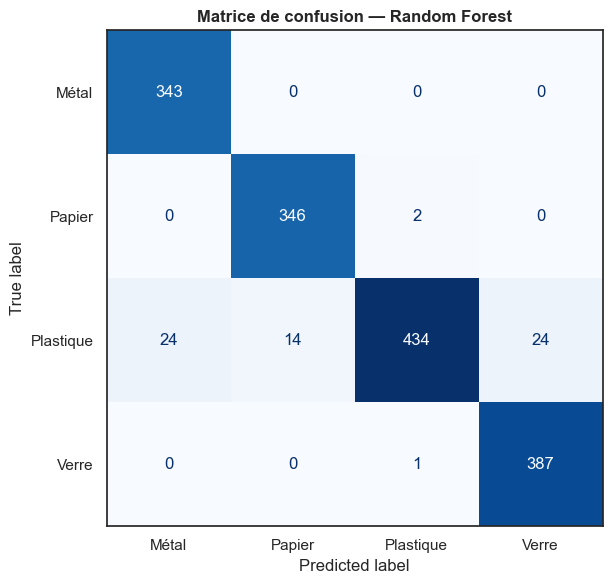

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_rf,
    display_labels=['Métal','Papier','Plastique','Verre'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Matrice de confusion — Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/confusion_matrix_rf.png', dpi=150)
plt.show()

#### Modèle 3 — XGBoost + Optuna

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Fonction objectif : Optuna cherche à maximiser l'accuracy de validation."""
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 400),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    preds = model.predict(X_val)
    return accuracy_score(y_val, preds)

# Lancer l'optimisation (30 essais)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)

print(f"=== XGBoost — Optuna ===")
print(f"Meilleurs hyperparamètres : {study.best_params}")
print(f"Meilleure accuracy (val)  : {study.best_value:.4f}")

# Réentraîner avec les meilleurs paramètres sur train complet
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42, n_jobs=-1,
    use_label_encoder=False, eval_metric='mlogloss'
)
best_xgb.fit(X_train, y_train)
preds_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, preds_xgb)
print(f"Accuracy (test) : {acc_xgb:.4f}")

=== XGBoost — Optuna ===
Meilleurs hyperparamètres : {'n_estimators': 116, 'max_depth': 10, 'learning_rate': 0.14896945298736244, 'subsample': 0.7838028204500994, 'colsample_bytree': 0.6860634654393921}
Meilleure accuracy (val)  : 0.9613
Accuracy (test) : 0.9575


#### Modèle 4 — SVM

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    'C':      [0.1, 1.0, 10.0],
    'kernel': ['rbf', 'linear'],
}
svm_base = SVC(random_state=42, probability=True)
gs_svm = GridSearchCV(svm_base, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_train, y_train)

best_svm = gs_svm.best_estimator_
preds_svm = best_svm.predict(X_test)
acc_svm = accuracy_score(y_test, preds_svm)

print(f"=== SVM — GridSearchCV ===")
print(f"Meilleurs hyperparamètres : {gs_svm.best_params_}")
print(f"Accuracy (test)           : {acc_svm:.4f}")

=== SVM — GridSearchCV ===
Meilleurs hyperparamètres : {'C': 1.0, 'kernel': 'rbf'}
Accuracy (test)           : 0.9537


#### Modèle 5 : KNN

In [ ]:

param_grid_knn = {
    'n_neighbors': list(range(1, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
gs_knn.fit(X_train, y_train)
best_knn = gs_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

acc_knn  = accuracy_score(y_test, y_pred_knn)
f1_knn   = f1_score(y_test, y_pred_knn, average='weighted')
prec_knn = precision_score(y_test, y_pred_knn, average='weighted')
rec_knn  = recall_score(y_test, y_pred_knn, average='weighted')

print(f"=== KNN — GridSearchCV ===")
print(f"Meilleurs params : {gs_knn.best_params_}")
print(f"Accuracy (test)  : {acc_knn:.4f} | F1 : {f1_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn,
      target_names=['Métal','Papier','Plastique','Verre']))

=== KNN — GridSearchCV ===
Meilleurs params : {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
Accuracy (test)  : 0.9581 | F1 : 0.9574

              precision    recall  f1-score   support

       Métal       0.93      1.00      0.97       343
      Papier       0.96      0.99      0.98       348
   Plastique       0.99      0.88      0.93       496
       Verre       0.94      1.00      0.97       388

    accuracy                           0.96      1575
   macro avg       0.96      0.97      0.96      1575
weighted avg       0.96      0.96      0.96      1575



#### Modèle 6 : Decision Tree

In [ ]:


param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
gs_dt.fit(X_train, y_train)
best_dt = gs_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt, average='weighted')
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test, y_pred_dt, average='weighted')

print(f"=== Decision Tree — GridSearchCV ===")
print(f"Meilleurs params : {gs_dt.best_params_}")
print(f"Accuracy (test)  : {acc_dt:.4f} | F1 : {f1_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Métal','Papier','Plastique','Verre']))

=== Decision Tree — GridSearchCV ===
Meilleurs params : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
Accuracy (test)  : 0.9568 | F1 : 0.9561

              precision    recall  f1-score   support

       Métal       0.93      0.99      0.96       343
      Papier       0.96      1.00      0.98       348
   Plastique       0.99      0.87      0.93       496
       Verre       0.94      0.99      0.97       388

    accuracy                           0.96      1575
   macro avg       0.96      0.96      0.96      1575
weighted avg       0.96      0.96      0.96      1575



### Comparaison de tous les modèles de classification

=== Classement des 6 modèles de classification ===


,Modèle,Accuracy (test),F1 (weighted)
0,Random Forest,0.9587,0.9580
1,KNN,0.9581,0.9574
2,XGBoost (Optuna),0.9575,0.9567
3,Decision Tree,0.9568,0.9561
4,Logistic Regression,0.9549,0.9540
5,SVM,0.9537,0.9528


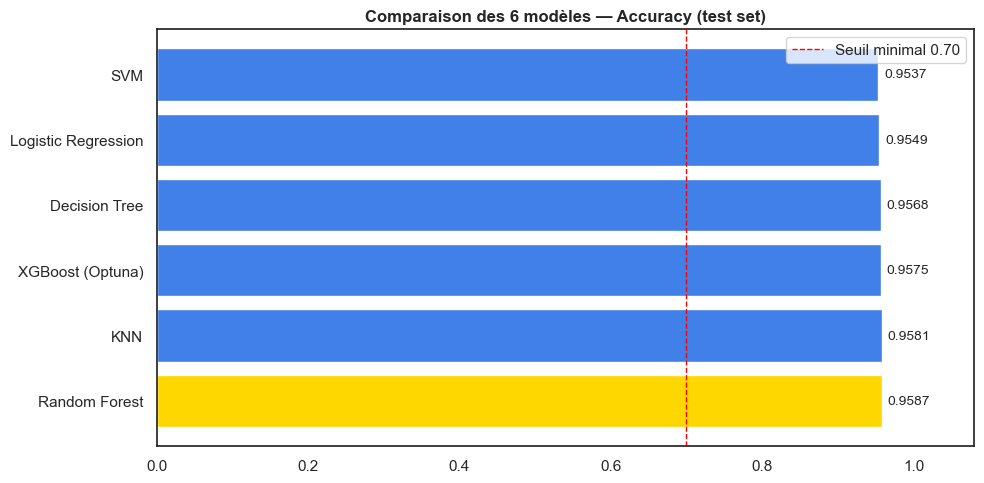


 Meilleur modèle : Random Forest (accuracy = 0.9587)
 Seuil minimal 0.70 atteint


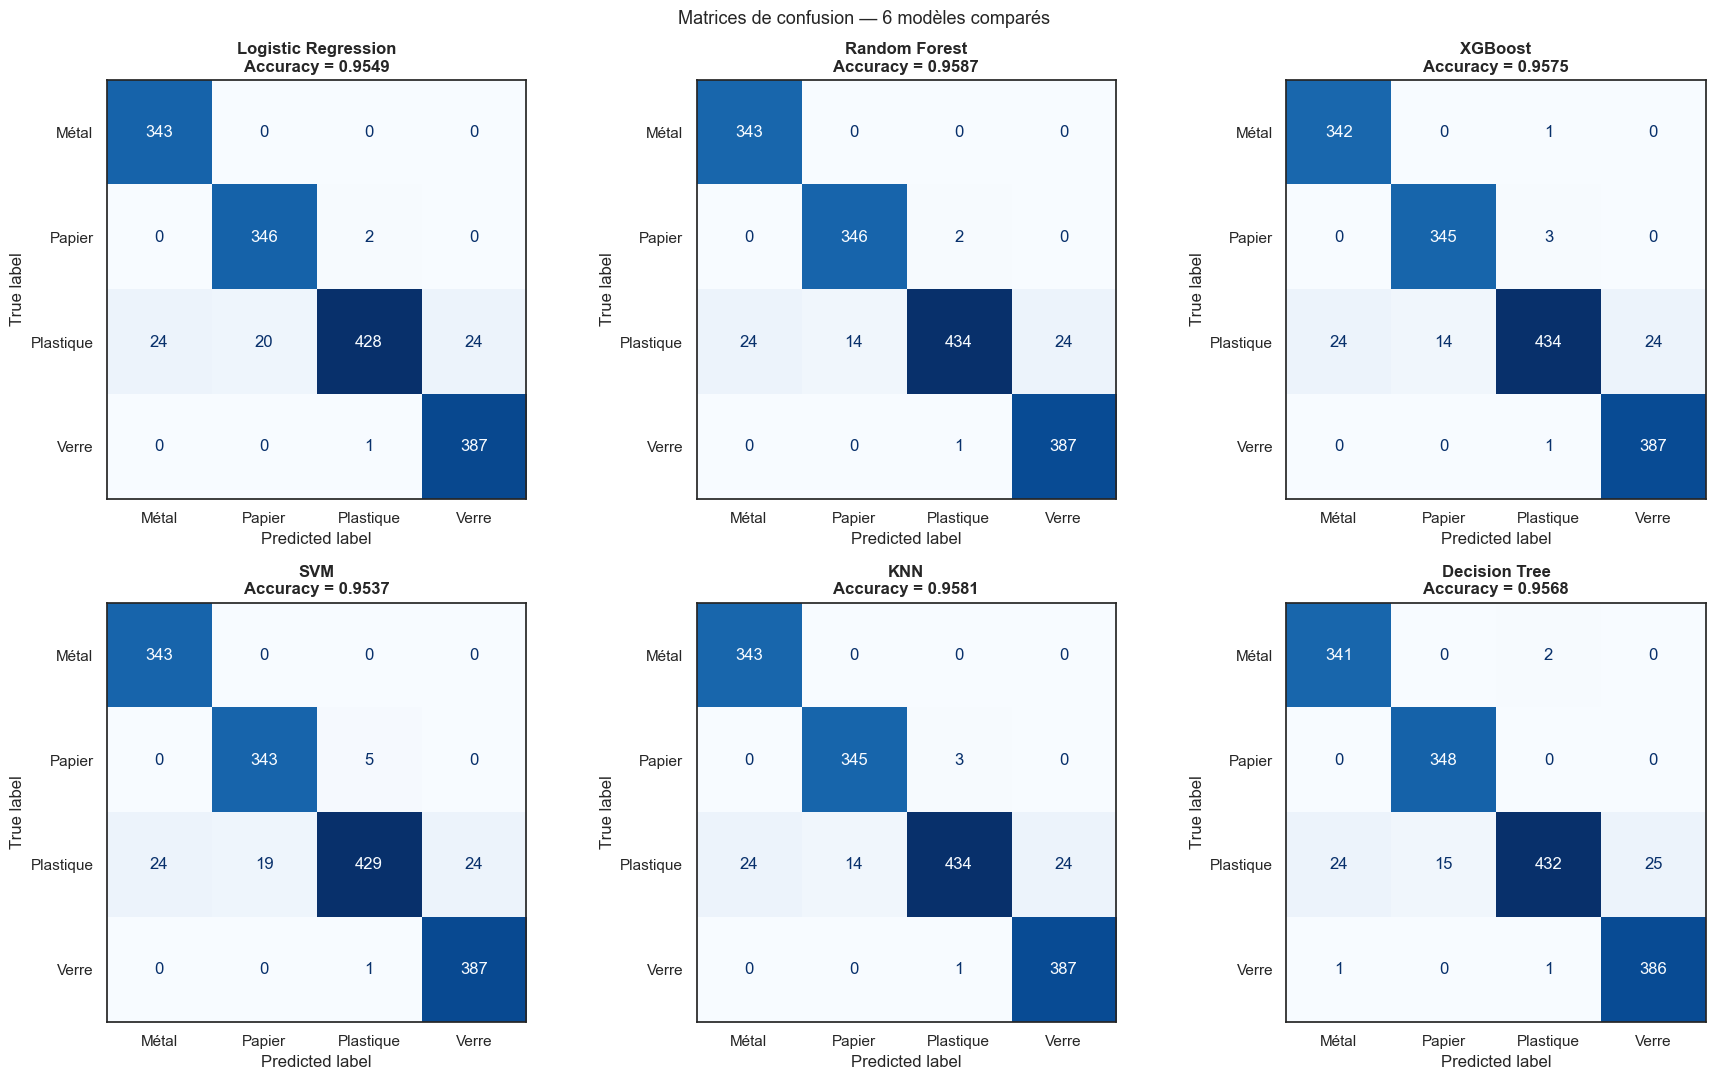

 Matrices de confusion sauvegardées.


In [ ]:
f1_lr  = f1_score(y_test, preds_lr,  average='weighted')
f1_rf  = f1_score(y_test, preds_rf,  average='weighted')
f1_xgb = f1_score(y_test, preds_xgb, average='weighted')
f1_svm = f1_score(y_test, preds_svm, average='weighted')

# ── Tableau comparatif complet (6 modèles) ──
resultats_clf = [
    ('Logistic Regression',  acc_lr,  f1_lr),
    ('Random Forest',        acc_rf,  f1_rf),
    ('XGBoost (Optuna)',     acc_xgb, f1_xgb),
    ('SVM',                  acc_svm, f1_svm),
    ('KNN',                  acc_knn, f1_knn),
    ('Decision Tree',        acc_dt,  f1_dt),
]

df_resultats = pd.DataFrame(
    resultats_clf,
    columns=['Modèle', 'Accuracy (test)', 'F1 (weighted)']
).sort_values('Accuracy (test)', ascending=False).reset_index(drop=True)

print("=== Classement des 6 modèles de classification ===")
display(df_resultats.style.format({
    'Accuracy (test)': '{:.4f}',
    'F1 (weighted)': '{:.4f}'
}).highlight_max(subset=['Accuracy (test)', 'F1 (weighted)'], color='#d4edda'))

# ── Barplot comparatif ──
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if v == df_resultats['Accuracy (test)'].max() else '#4080E8'
          for v in df_resultats['Accuracy (test)']]
bars = ax.barh(df_resultats['Modèle'], df_resultats['Accuracy (test)'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_xlim(0, 1.08)
ax.axvline(x=0.70, color='red', linestyle='--', linewidth=1, label='Seuil minimal 0.70')
ax.set_title('Comparaison des 6 modèles — Accuracy (test set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./data/processed/comparaison_modeles_clf.png', dpi=150)
plt.show()

# Vérification seuil minimal
meilleur_acc = df_resultats['Accuracy (test)'].max()
meilleur_nom = df_resultats.iloc[0]['Modèle']
assert meilleur_acc >= 0.70, f"Accuracy {meilleur_acc:.4f} < seuil minimal 0.70"
print(f"\n Meilleur modèle : {meilleur_nom} (accuracy = {meilleur_acc:.4f})")
print(f" Seuil minimal 0.70 atteint")

# ── Matrices de confusion — 6 modèles côte à côte ──
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

modeles_preds = [
    ('Logistic Regression',  preds_lr),
    ('Random Forest',        preds_rf),
    ('XGBoost',              preds_xgb),
    ('SVM',                  preds_svm),
    ('KNN',                  y_pred_knn),
    ('Decision Tree',        y_pred_dt),
]

for ax, (nom, preds) in zip(axes, modeles_preds):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['Métal','Papier','Plastique','Verre'],
        cmap='Blues', ax=ax, colorbar=False
    )
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{nom}\nAccuracy = {acc:.4f}', fontweight='bold')

plt.suptitle('Matrices de confusion — 6 modèles comparés', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Matrices de confusion sauvegardées.")

### Sélection de features avec SHAP Values

X_test shape: (1575, 6)
SHAP values shape: (1575, 6, 4)


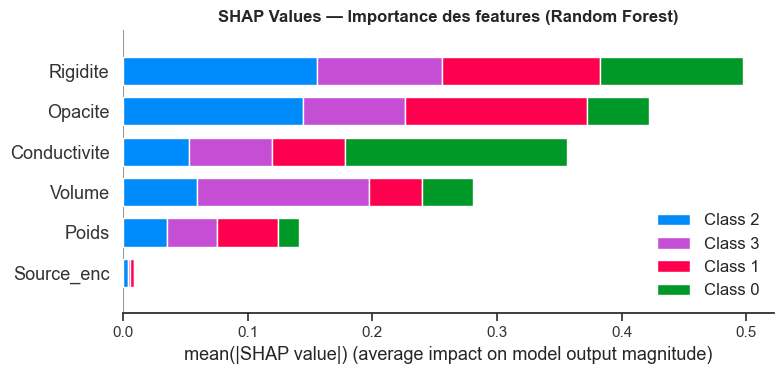

In [ ]:
import shap
import matplotlib.pyplot as plt

#  Création de l'explainer SHAP
explainer = shap.TreeExplainer(best_rf)

#  Calcul des SHAP values (format moderne recommandé)
shap_values = explainer(X_test)

#  Vérification (optionnel mais utile)
print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_values.values.shape)

#  Summary plot (importance globale des features)
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values.values,   # IMPORTANT : .values ici
    X_test,
    feature_names=X_test.columns,  # plus sûr que FEATURES
    plot_type="bar",
    show=False
)

plt.title("SHAP Values — Importance des features (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

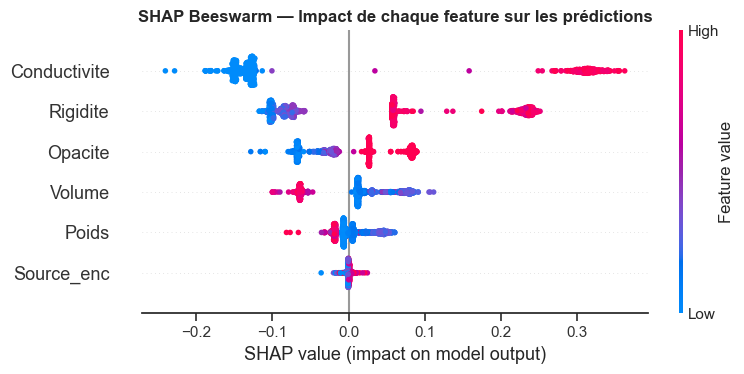

=== Importance SHAP (classe Métal) ===


,Feature,SHAP moyen
2,Conductivite,0.178044
4,Rigidite,0.114737
3,Opacite,0.049536
1,Volume,0.040629
0,Poids,0.016970
5,Source_enc,0.001495



→ Les features avec SHAP ≈ 0 peuvent être supprimées pour simplifier le modèle


In [ ]:
# SHAP Beeswarm plot — distribution des impacts
fig = plt.figure(figsize=(10, 6))

#  choisir une seule classe (ex: classe 0 = Métal)
shap.summary_plot(
    shap_values.values[:, :, 0],   # ✅ FIX IMPORTANT
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.title('SHAP Beeswarm — Impact de chaque feature sur les prédictions', fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/shap_beeswarm.png', dpi=150)
plt.show()


# =========================
# Importance moyenne par feature
# =========================

#  on prend la même classe
mean_shap = np.abs(shap_values.values[:, :, 0]).mean(axis=0)

df_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP moyen': mean_shap
}).sort_values('SHAP moyen', ascending=False)

print("=== Importance SHAP (classe Métal) ===")
display(df_shap)

print()
print("→ Les features avec SHAP ≈ 0 peuvent être supprimées pour simplifier le modèle")

### Tracking des expériences avec MLflow

In [ ]:
import os
import mlflow
import mlflow.sklearn
import logging
logging.getLogger("mlflow").setLevel(logging.ERROR)

# =========================
# CONFIG MLflow
# =========================
os.makedirs('./mlruns', exist_ok=True)

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("eco_smart_classifier")


# =========================
# RUN 1 : Logistic Regression
# =========================
with mlflow.start_run(run_name="LogisticRegression"):

    mlflow.log_params({
        "model": "logistic_regression",
        "C": 1.0,
        "max_iter": 500
    })

    mlflow.log_metric("accuracy_test", acc_lr)

    mlflow.sklearn.log_model(lr, name="model")

    print(f"✓ Run 1 — Logistic Regression : {acc_lr:.4f}")


# =========================
# RUN 2 : Random Forest
# =========================
with mlflow.start_run(run_name="RandomForest_GridSearch"):

    mlflow.log_params({
        "model": "random_forest",
        **gs_rf.best_params_
    })

    mlflow.log_metric("accuracy_test", acc_rf)
    mlflow.log_metric("accuracy_cv", gs_rf.best_score_)

    mlflow.sklearn.log_model(best_rf, name="model")

    mlflow.log_artifact("./data/processed/confusion_matrix_rf.png")
    mlflow.log_artifact("./data/processed/shap_beeswarm.png")  # ✔ corrected filename

    print(f"✓ Run 2 — Random Forest : {acc_rf:.4f}")


# =========================
# RUN 3 : XGBoost
# =========================
with mlflow.start_run(run_name="XGBoost_Optuna"):

    mlflow.log_params({
        "model": "xgboost_optuna",
        **study.best_params
    })

    mlflow.log_metric("accuracy_test", acc_xgb)
    mlflow.log_metric("accuracy_val", study.best_value)

    mlflow.sklearn.log_model(best_xgb, name="model")

    print(f"✓ Run 3 — XGBoost : {acc_xgb:.4f}")


# =========================
# RUN 4 : SVM
# =========================
with mlflow.start_run(run_name="SVM_GridSearch"):

    mlflow.log_params({
        "model": "svm",
        **gs_svm.best_params_
    })

    mlflow.log_metric("accuracy_test", acc_svm)

    mlflow.sklearn.log_model(best_svm, name="model")

    print(f"✓ Run 4 — SVM : {acc_svm:.4f}")

# Run 5 — KNN
with mlflow.start_run(run_name="KNN_GridSearch"):
    mlflow.log_params({"model": "knn", **gs_knn.best_params_})
    mlflow.log_metric("accuracy_test", acc_knn)
    mlflow.log_metric("f1_weighted", f1_knn)
    mlflow.sklearn.log_model(best_knn, artifact_path="model")
    print(f"✓ Run 5 — KNN : {acc_knn:.4f}")

# Run 6 — Decision Tree
with mlflow.start_run(run_name="DecisionTree_GridSearch"):
    mlflow.log_params({"model": "decision_tree", **gs_dt.best_params_})
    mlflow.log_metric("accuracy_test", acc_dt)
    mlflow.log_metric("f1_weighted", f1_dt)
    mlflow.sklearn.log_model(best_dt, artifact_path="model")
    print(f"✓ Run 6 — Decision Tree : {acc_dt:.4f}")


# =========================
# INFO
# =========================
print("\n✔ MLflow runs completed successfully")
print("👉 Lance dans terminal : mlflow ui")
print("👉 Puis ouvre : http://localhost:5000")

✓ Run 1 — Logistic Regression : 0.9549
✓ Run 2 — Random Forest : 0.9587
✓ Run 3 — XGBoost : 0.9575
✓ Run 4 — SVM : 0.9537
✓ Run 5 — KNN : 0.9581
✓ Run 6 — Decision Tree : 0.9568

✔ MLflow runs completed successfully
👉 Lance dans terminal : mlflow ui
👉 Puis ouvre : http://localhost:5000


In [ ]:
# Sauvegarder le meilleur modèle pour l'API
modeles_dict = {
    'Logistic Regression': lr,
    'Random Forest': best_rf,
    'XGBoost (Optuna)': best_xgb,
    'SVM': best_svm,
    'KNN':                  best_knn,
    'Decision Tree':        best_dt,
}
accs_dict = {
    'Logistic Regression': acc_lr,
    'Random Forest': acc_rf,
    'XGBoost (Optuna)': acc_xgb,
    'SVM': acc_svm,
    'KNN':                  acc_knn,
    'Decision Tree':        acc_dt,
}

meilleur_nom = max(accs_dict, key=accs_dict.get)
meilleur_modele = modeles_dict[meilleur_nom]

joblib.dump(meilleur_modele, './data/processed/best_classifier.pkl')
print(f" Meilleur classifieur sauvegardé : {meilleur_nom}")
print(f"   Accuracy test : {accs_dict[meilleur_nom]:.4f}")
print(f"   Fichier : ./data/processed/best_classifier.pkl")

# MLflow — enregistrer au Model Registry
with mlflow.start_run(run_name=f'BestModel_{meilleur_nom.replace(" ","_")}'):
    mlflow.log_params({'best_model': meilleur_nom})
    mlflow.log_metric('accuracy_test', accs_dict[meilleur_nom])
    mlflow.sklearn.log_model(
        meilleur_modele, 'best_classifier',
        registered_model_name='eco_smart_classifier'
    )
    print(f"✓ Run 5 — Best model enregistré au MLflow Registry")

 Meilleur classifieur sauvegardé : Random Forest
   Accuracy test : 0.9587
   Fichier : ./data/processed/best_classifier.pkl


Registered model 'eco_smart_classifier' already exists. Creating a new version of this model...


✓ Run 5 — Best model enregistré au MLflow Registry


Created version '7' of model 'eco_smart_classifier'.


### Partie 2 : Régression — Prédire `Prix_Revente`

In [ ]:
# Features et target régression

In [ ]:
X_train_reg = df_train[FEATURES]
X_test_reg  = df_test[FEATURES]
y_train_reg = df_train['Prix_Revente']
y_test_reg  = df_test['Prix_Revente']

print(f"Target régression — stats :")
print(f"  Min : {y_train_reg.min():.2f}")
print(f"  Max : {y_train_reg.max():.2f}")
print(f"  Mean: {y_train_reg.mean():.2f}")
print(f"  Std : {y_train_reg.std():.2f}")

Target régression — stats :
  Min : 0.00
  Max : 14.77
  Mean: 5.63
  Std : 5.01


#### Modèle Régression 1 — Ridge Regression + GridSearchCV

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
gs_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=3, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train_reg, y_train_reg)

best_ridge = gs_ridge.best_estimator_
preds_ridge = best_ridge.predict(X_test_reg)

mae_ridge  = mean_absolute_error(y_test_reg, preds_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_reg, preds_ridge))
r2_ridge   = r2_score(y_test_reg, preds_ridge)

print(f"=== Ridge Regression ===")
print(f"Meilleur alpha : {gs_ridge.best_params_['alpha']}")
print(f"MAE  : {mae_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

=== Ridge Regression ===
Meilleur alpha : 0.1
MAE  : 0.8736
RMSE : 1.4048
R²   : 0.9213


#### Modèle Régression 2 — Random Forest Regressor

In [ ]:
rfr = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rfr.fit(X_train_reg, y_train_reg)
preds_rfr = rfr.predict(X_test_reg)

mae_rfr  = mean_absolute_error(y_test_reg, preds_rfr)
rmse_rfr = np.sqrt(mean_squared_error(y_test_reg, preds_rfr))
r2_rfr   = r2_score(y_test_reg, preds_rfr)

print(f"=== Random Forest Regressor ===")
print(f"MAE  : {mae_rfr:.4f}")
print(f"RMSE : {rmse_rfr:.4f}")
print(f"R²   : {r2_rfr:.4f}")

=== Random Forest Regressor ===
MAE  : 0.0476
RMSE : 0.4502
R²   : 0.9919


#### Modèle Régression 3 — XGBoost Regressor

In [ ]:
xgbr = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
xgbr.fit(X_train_reg, y_train_reg)
preds_xgbr = xgbr.predict(X_test_reg)

mae_xgbr  = mean_absolute_error(y_test_reg, preds_xgbr)
rmse_xgbr = np.sqrt(mean_squared_error(y_test_reg, preds_xgbr))
r2_xgbr   = r2_score(y_test_reg, preds_xgbr)

print(f"=== XGBoost Regressor ===")
print(f"MAE  : {mae_xgbr:.4f}")
print(f"RMSE : {rmse_xgbr:.4f}")
print(f"R²   : {r2_xgbr:.4f}")

=== XGBoost Regressor ===
MAE  : 0.1023
RMSE : 0.4934
R²   : 0.9903


#### Comparaison des modèles de régression

=== Comparaison modèles de régression ===


,Modèle,MAE,RMSE,R²
1,Random Forest Regressor,0.0476,0.4502,0.9919
2,XGBoost Regressor,0.1023,0.4934,0.9903
0,Ridge,0.8736,1.4048,0.9213


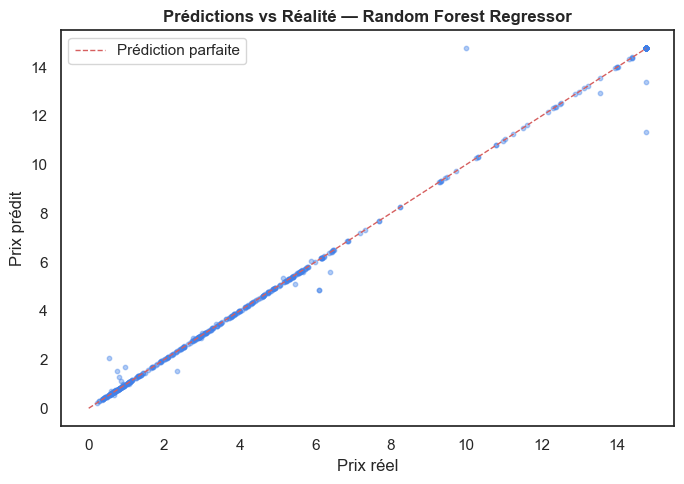

In [ ]:
df_reg = pd.DataFrame({
    'Modèle': ['Ridge', 'Random Forest Regressor', 'XGBoost Regressor'],
    'MAE':  [mae_ridge, mae_rfr, mae_xgbr],
    'RMSE': [rmse_ridge, rmse_rfr, rmse_xgbr],
    'R²':   [r2_ridge, r2_rfr, r2_xgbr],
}).sort_values('R²', ascending=False)

print("=== Comparaison modèles de régression ===")
display(df_reg.style.format({'MAE':'{:.4f}','RMSE':'{:.4f}','R²':'{:.4f}'}))

# Scatter plot : prédictions vs réelles (meilleur modèle)
best_reg_name = df_reg.iloc[0]['Modèle']
best_preds_reg = {
    'Ridge': preds_ridge,
    'Random Forest Regressor': preds_rfr,
    'XGBoost Regressor': preds_xgbr
}[best_reg_name]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg[:500], best_preds_reg[:500], alpha=0.4, s=10, color='#4080E8')
lim = max(y_test_reg.max(), best_preds_reg.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Prédiction parfaite')
ax.set_xlabel('Prix réel')
ax.set_ylabel('Prix prédit')
ax.set_title(f'Prédictions vs Réalité — {best_reg_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./data/processed/regression_scatter.png', dpi=150)
plt.show()

In [ ]:
#### Générer la nouvelle colonne Prix_Revente_predit

In [ ]:
best_reg_models = {
    'Ridge': best_ridge,
    'Random Forest Regressor': rfr,
    'XGBoost Regressor': xgbr,
}
best_reg_name_final = df_reg.iloc[0]['Modèle']
best_reg = best_reg_models[best_reg_name_final]

# Ajouter la colonne prédite sur tout le dataset labellisé
df_train_out = df_train.copy()
df_test_out  = df_test.copy()

df_train_out['Prix_Revente_predit'] = best_reg.predict(df_train[FEATURES])
df_test_out['Prix_Revente_predit']  = best_reg.predict(df_test[FEATURES])

print(f" Nouvelle colonne 'Prix_Revente_predit' générée")
print(f"   Modèle utilisé : {best_reg_name_final}")
print()
display(df_test_out[['Poids','Categorie','Prix_Revente','Prix_Revente_predit']].head(8))

# Sauvegarder le meilleur régresseur
joblib.dump(best_reg, './data/processed/best_regressor.pkl')
print(f"\n Régresseur sauvegardé : ./data/processed/best_regressor.pkl")

# MLflow — enregistrer le régresseur
with mlflow.start_run(run_name=f'Regressor_{best_reg_name_final.replace(" ","_")}'):
    mlflow.log_params({'model': best_reg_name_final})
    mlflow.log_metric('mae',  df_reg.iloc[0]['MAE'])
    mlflow.log_metric('rmse', df_reg.iloc[0]['RMSE'])
    mlflow.log_metric('r2',   df_reg.iloc[0]['R²'])
    mlflow.sklearn.log_model(best_reg, 'regressor',
                             registered_model_name='eco_smart_regressor')
    print(f"✓ Run 6 — Régresseur enregistré dans MLflow")

 Nouvelle colonne 'Prix_Revente_predit' générée
   Modèle utilisé : Random Forest Regressor



,Poids,Categorie,Prix_Revente,Prix_Revente_predit
0,-0.287724,Métal,14.770781,14.770781
1,-0.663017,Papier,1.306505,1.306505
2,0.669326,Verre,3.643993,3.645192
3,-0.726055,Papier,1.080969,1.080969
4,-0.712207,Papier,0.866679,1.107100
5,1.243849,Verre,4.877300,4.879147
6,-0.842941,Plastique,1.325556,1.325579
7,-0.807050,Plastique,1.582376,1.582376



 Régresseur sauvegardé : ./data/processed/best_regressor.pkl


Registered model 'eco_smart_regressor' already exists. Creating a new version of this model...


✓ Run 6 — Régresseur enregistré dans MLflow


Created version '7' of model 'eco_smart_regressor'.


## Module 3 : Clustering — Analyse Non-Supervisée

#### Imports et préparation des données pour le clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# ── Charger tous les splits + données non-labellisées ──
df_train_clu = pd.read_csv('./data/processed/train.csv')
df_val_clu   = pd.read_csv('./data/processed/val.csv')
df_test_clu  = pd.read_csv('./data/processed/test.csv')
df_unlab_clu = pd.read_csv('./data/processed/unlabeled.csv')

# Concaténer TOUT le dataset (labeled + unlabeled)
df_all = pd.concat([df_train_clu, df_val_clu, df_test_clu, df_unlab_clu], ignore_index=True)

# Features numériques uniquement — PAS les labels
FEATURES_CLU = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_enc']
X_clu = df_all[FEATURES_CLU].copy()

print(f"Shape total pour le clustering : {X_clu.shape}")
print(f"Dont labellisés  : {df_all['Categorie'].notna().sum()}")
print(f"Dont unlabelled  : {df_all['Categorie'].isna().sum()}")
print(f"\n⚠️  Les labels sont ignorés — l'algorithme découvre les groupes seul.")

Shape total pour le clustering : (10500, 6)
Dont labellisés  : 10500
Dont unlabelled  : 0

⚠️  Les labels sont ignorés — l'algorithme découvre les groupes seul.


#### Étape 1 — Méthode du Coude (Elbow Method) + Silhouette Score

In [ ]:
inerties    = []
silhouettes = []
K_range     = range(2, 11)

print("K  | Inertie        | Silhouette")
print("-" * 40)
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clu)
    inerties.append(km.inertia_)
    sil = silhouette_score(X_clu, lbl)
    silhouettes.append(sil)
    print(f"K={k:2d} | {km.inertia_:14,.1f} | {sil:.4f}")

K  | Inertie        | Silhouette
----------------------------------------
K= 2 |       37,452.0 | 0.4480
K= 3 |       20,910.3 | 0.5327
K= 4 |       16,039.6 | 0.4700
K= 5 |       13,616.1 | 0.4350
K= 6 |       11,351.7 | 0.4279
K= 7 |        9,439.7 | 0.4363
K= 8 |        7,898.1 | 0.4688
K= 9 |        7,049.1 | 0.4762
K=10 |        6,570.4 | 0.4540


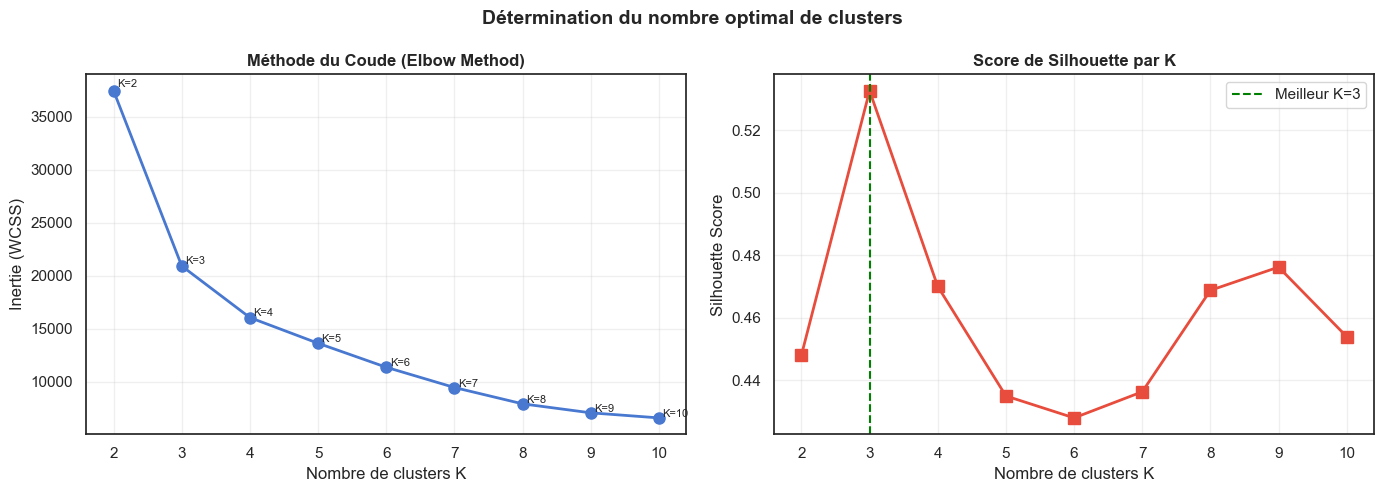


 Silhouette max : 0.5327 pour K=3
   On s'attend à K=4 (4 catégories : Métal, Papier, Plastique, Verre)


In [ ]:
# ── Graphique Elbow + Silhouette ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inerties, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters K', fontsize=12)
axes[0].set_ylabel('Inertie (WCSS)', fontsize=12)
axes[0].set_title('Méthode du Coude (Elbow Method)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
for k, iner in zip(K_range, inerties):
    axes[0].annotate(f'K={k}', xy=(k, iner), xytext=(k+0.05, iner*1.01), fontsize=8)

# Silhouette
axes[1].plot(K_range, silhouettes, 's-', linewidth=2, markersize=8, color='#E74C3C')
axes[1].set_xlabel('Nombre de clusters K', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Score de Silhouette par K', fontweight='bold')
axes[1].grid(True, alpha=0.3)
best_k_sil = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', label=f'Meilleur K={best_k_sil}')
axes[1].legend()

plt.suptitle('Détermination du nombre optimal de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/elbow_silhouette.png', dpi=150)
plt.show()

print(f"\n Silhouette max : {max(silhouettes):.4f} pour K={best_k_sil}")
print(f"   On s'attend à K=4 (4 catégories : Métal, Papier, Plastique, Verre)")

#### Étape 2 — Entraînement K-Means avec K=4

In [ ]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans.fit_predict(X_clu)

df_all['Cluster'] = cluster_labels

print(f"=== K-Means K={K_OPTIMAL} ===")
print(f"Inertie        : {kmeans.inertia_:,.2f}")
print(f"Silhouette     : {silhouette_score(X_clu, cluster_labels):.4f}")

print(f"\nRépartition des clusters :")
print(df_all['Cluster'].value_counts().sort_index())

# Crosstab clusters vs catégories réelles (seulement les labellisés)
print(f"\n=== Clusters vs Catégories réelles ===")
df_labeled_clu = df_all[df_all['Categorie'].notna()]
cross = pd.crosstab(df_labeled_clu['Cluster'], df_labeled_clu['Categorie'])
display(cross)

=== K-Means K=4 ===
Inertie        : 16,039.58
Silhouette     : 0.4700

Répartition des clusters :
Cluster
0    2462
1    2450
2    2672
3    2916
Name: count, dtype: int64

=== Clusters vs Catégories réelles ===


Categorie,Métal,Papier,Plastique,Verre
Cluster,,,,
0,2286,0,127,49
1,0,1095,1355,0
2,1,1,133,2537
3,0,1222,1694,0


#### Étape 3 — Réduction PCA et visualisation 2D

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clu)

var1      = pca.explained_variance_ratio_[0] * 100
var2      = pca.explained_variance_ratio_[1] * 100
var_total = var1 + var2

print(f"=== PCA — Variance expliquée ===")
print(f"  PC1 : {var1:.1f}%")
print(f"  PC2 : {var2:.1f}%")
print(f"  Total (2D) : {var_total:.1f}%")
print(" Représentation fiable" if var_total >= 60 else "  Perte d'information — interpréter avec prudence")

# Contribution des features
df_loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES_CLU,
    columns=['PC1', 'PC2']
).round(3)
print("\n=== Contribution des features aux composantes ===")
display(df_loadings)

=== PCA — Variance expliquée ===
  PC1 : 48.2%
  PC2 : 25.1%
  Total (2D) : 73.3%
 Représentation fiable

=== Contribution des features aux composantes ===


,PC1,PC2
Poids,0.552,0.007
Volume,0.558,0.006
Conductivite,-0.038,0.779
Opacite,-0.410,0.440
Rigidite,0.462,0.443
Source_enc,0.031,-0.055


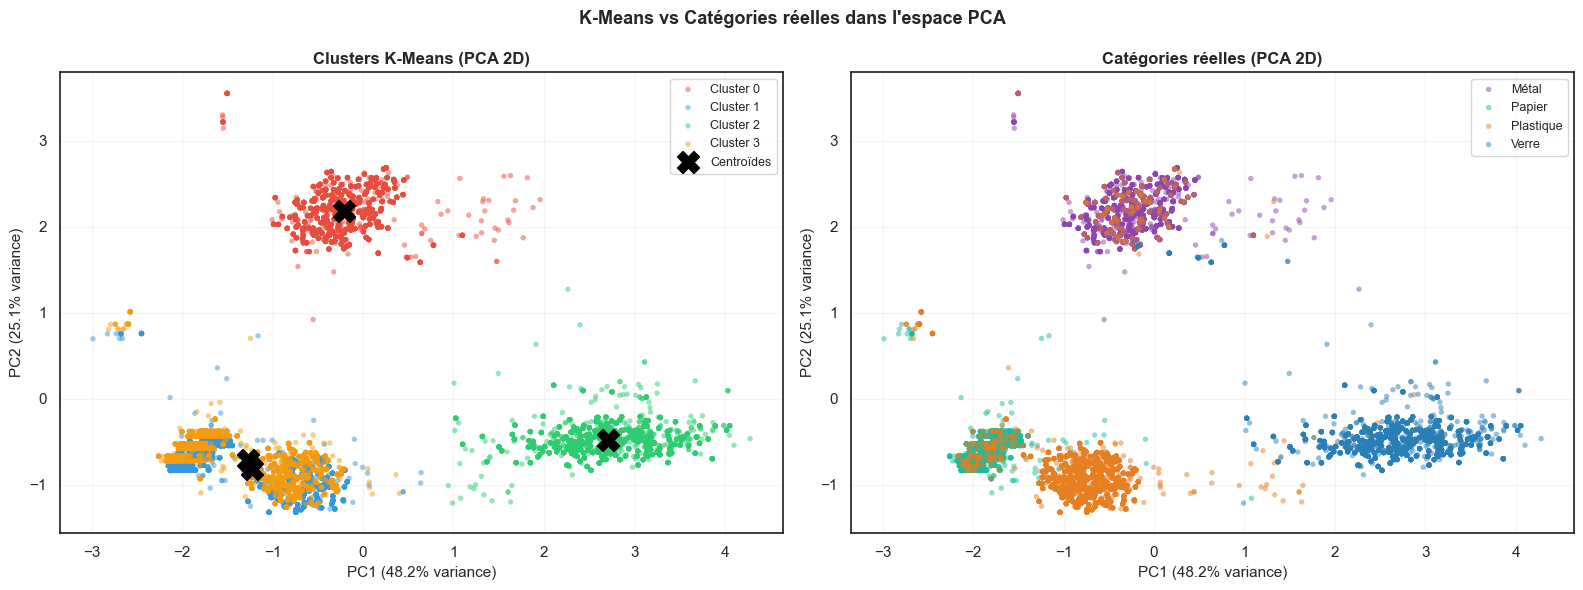

 Visualisation PCA sauvegardée.


In [ ]:
# ── Visualisation côte à côte : Clusters K-Means vs Catégories réelles ──
couleurs_clusters = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
couleurs_cat      = {'Métal': '#8E44AD', 'Papier': '#1ABC9C',
                     'Plastique': '#E67E22', 'Verre': '#2980B9',
                     'Non labellisé': '#95A5A6'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Clusters K-Means ---
ax = axes[0]
for i in range(K_OPTIMAL):
    mask = cluster_labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=couleurs_clusters[i], label=f'Cluster {i}',
               alpha=0.5, s=15, edgecolors='none')
# Centroïdes
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', marker='X', s=250, zorder=5, label='Centroïdes')
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=11)
ax.set_title('Clusters K-Means (PCA 2D)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# --- Catégories réelles ---
ax2 = axes[1]
categories = df_all['Categorie'].fillna('Non labellisé')
for cat, couleur in couleurs_cat.items():
    mask = categories == cat
    if mask.any():
        ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=couleur, label=cat,
                    alpha=0.5, s=15, edgecolors='none')
ax2.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=11)
ax2.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=11)
ax2.set_title('Catégories réelles (PCA 2D)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

plt.suptitle('K-Means vs Catégories réelles dans l\'espace PCA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Visualisation PCA sauvegardée.")

#### Étape 4 — Profil et interprétation des clusters

=== Profil moyen par cluster (valeurs standardisées) ===


,Poids,Volume,Conductivite,Opacite,Rigidite,Source_enc
Cluster,,,,,,
0,-0.128,-0.141,1.774,0.967,0.863,1.429
1,-0.688,-0.718,-0.548,0.175,-0.917,2.490
2,1.520,1.564,-0.533,-1.214,1.026,1.519
3,-0.706,-0.711,-0.549,0.150,-0.899,0.578


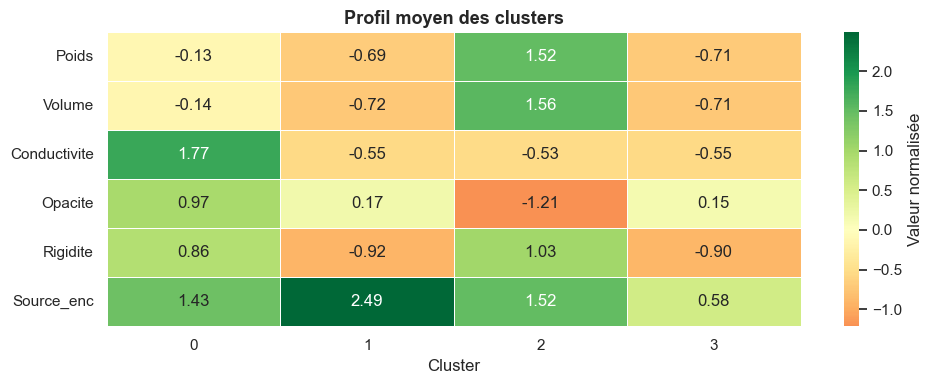


=== Distribution des catégories réelles dans chaque cluster (%) ===


Categorie,Métal,Papier,Plastique,Verre
Cluster,,,,
0,92.9%,0.0%,5.2%,2.0%
1,0.0%,44.7%,55.3%,0.0%
2,0.0%,0.0%,5.0%,94.9%
3,0.0%,41.9%,58.1%,0.0%


→ Un cluster dominé à >60% par une catégorie = cluster cohérent


In [ ]:
# Profil moyen par cluster
profil = df_all.groupby('Cluster')[FEATURES_CLU].mean().round(3)
print("=== Profil moyen par cluster (valeurs standardisées) ===")
display(profil)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profil.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Valeur normalisée'})
ax.set_title('Profil moyen des clusters', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/cluster_profiles.png', dpi=150)
plt.show()

# Distribution % des catégories dans chaque cluster
print("\n=== Distribution des catégories réelles dans chaque cluster (%) ===")
df_lab = df_all[df_all['Categorie'].notna()]
cross_pct = pd.crosstab(df_lab['Cluster'], df_lab['Categorie'], normalize='index').round(3) * 100
display(cross_pct.style.format('{:.1f}%').background_gradient(cmap='Blues', axis=1))
print("→ Un cluster dominé à >60% par une catégorie = cluster cohérent")

#### Étape 5 — Évaluation formelle du clustering

In [ ]:
# Métriques internes
sil_score = silhouette_score(X_clu, cluster_labels)

# Métriques externes (sur données labellisées seulement)
df_lab2    = df_all[df_all['Categorie'].notna()].copy()
le_clu     = joblib.load('./data/processed/label_encoder.pkl')   # ← ton LabelEncoder du module 1
y_true_enc = le_clu.transform(df_lab2['Categorie'])
y_pred_clu = df_lab2['Cluster'].values

ari = adjusted_rand_score(y_true_enc, y_pred_clu)
nmi = normalized_mutual_info_score(y_true_enc, y_pred_clu)

print("=== Métriques de qualité du clustering ===")
print(f"  Silhouette Score       : {sil_score:.4f}  ([-1,1], proche de 1 = bien séparé)")
print(f"  Inertie (WCSS)         : {kmeans.inertia_:,.2f}")
print(f"  Adjusted Rand Index    : {ari:.4f}  (0=aléatoire, 1=parfait)")
print(f"  NMI Score              : {nmi:.4f}  (0=indépendant, 1=parfait)")
print()
if ari > 0.5:
    print(" ARI > 0.5 : les clusters correspondent bien aux catégories réelles")
elif ari > 0.2:
    print("  ARI 0.2-0.5 : correspondance partielle — structure présente mais imparfaite")
else:
    print("  ARI < 0.2 : les clusters capturent une structure différente des catégories")
print("\n→ Si ARI est faible : les features numériques seules ne suffisent pas.")
print("   C'est la justification du Module 4 (NLP) pour apporter une information complémentaire.")

=== Métriques de qualité du clustering ===
  Silhouette Score       : 0.4700  ([-1,1], proche de 1 = bien séparé)
  Inertie (WCSS)         : 16,039.58
  Adjusted Rand Index    : 0.5747  (0=aléatoire, 1=parfait)
  NMI Score              : 0.6547  (0=indépendant, 1=parfait)

 ARI > 0.5 : les clusters correspondent bien aux catégories réelles

→ Si ARI est faible : les features numériques seules ne suffisent pas.
   C'est la justification du Module 4 (NLP) pour apporter une information complémentaire.


In [ ]:
# ── Sauvegarde des modèles pour l'application web ──
joblib.dump(kmeans, './data/processed/kmeans_model.pkl')
joblib.dump(pca,    './data/processed/pca_model.pkl')

df_pca_export = pd.DataFrame({
    'PC1':      X_pca[:, 0],
    'PC2':      X_pca[:, 1],
    'Cluster':  cluster_labels,
    'Categorie': df_all['Categorie'].fillna('Non labellisé').values
})
df_pca_export.to_csv('./data/processed/pca_clusters.csv', index=False)

print(" Fichiers sauvegardés :")
print("   ./data/processed/kmeans_model.pkl")
print("   ./data/processed/pca_model.pkl")
print("   ./data/processed/pca_clusters.csv")
print()
print("=== Résumé Module 3 ===")
print(f"  K choisi         : {K_OPTIMAL}")
print(f"  Silhouette Score : {sil_score:.4f}")
print(f"  Variance PCA 2D  : {var_total:.1f}%")
print(f"  ARI              : {ari:.4f}")
print(f"  NMI              : {nmi:.4f}")

 Fichiers sauvegardés :
   ./data/processed/kmeans_model.pkl
   ./data/processed/pca_model.pkl
   ./data/processed/pca_clusters.csv

=== Résumé Module 3 ===
  K choisi         : 4
  Silhouette Score : 0.4700
  Variance PCA 2D  : 73.3%
  ARI              : 0.5747
  NMI              : 0.6547


## Module 4 : Extracteur de Caractéristiques NLP

#### Installation des dépendances NLP

In [ ]:
# ── Imports NLP ──
import re
import string
from collections import Counter

import nltk
nltk.download('punkt',     quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression as LR_NLP
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier as RFC_NLP
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from scipy.sparse import issparse, hstack
import numpy as np

print("✅ Imports NLP OK")

✅ Imports NLP OK


#### 4.1 — Chargement et analyse de la colonne Rapport_Collecte

In [ ]:
# ── Recharger le dataset ORIGINAL (contient Rapport_Collecte) ──
df_raw = pd.read_csv('./data/dataset_ProjetML_2026.csv')

print("=== Aperçu de Rapport_Collecte ===")
print(f"Nombre total de lignes     : {len(df_raw)}")
print(f"Valeurs nulles             : {df_raw['Rapport_Collecte'].isna().sum()}")
print(f"Longueur moyenne           : {df_raw['Rapport_Collecte'].dropna().str.len().mean():.0f} caractères")
print()

# Afficher 3 exemples pour comprendre le contenu
print("--- 3 exemples de rapports ---")
for i, txt in enumerate(df_raw['Rapport_Collecte'].dropna().head(3)):
    print(f"\n[Exemple {i+1}] {txt}")

=== Aperçu de Rapport_Collecte ===
Nombre total de lignes     : 10500
Valeurs nulles             : 0
Longueur moyenne           : 145 caractères

--- 3 exemples de rapports ---

[Exemple 1] Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.

[Exemple 2] Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucune trace de métal.

[Exemple 3] Bris de verre ou contenants en provenance de l'Usine B. Masse non mesuré kg. Matériau dense, rigidité élevée, transparence partielle. Légère contamination observée.


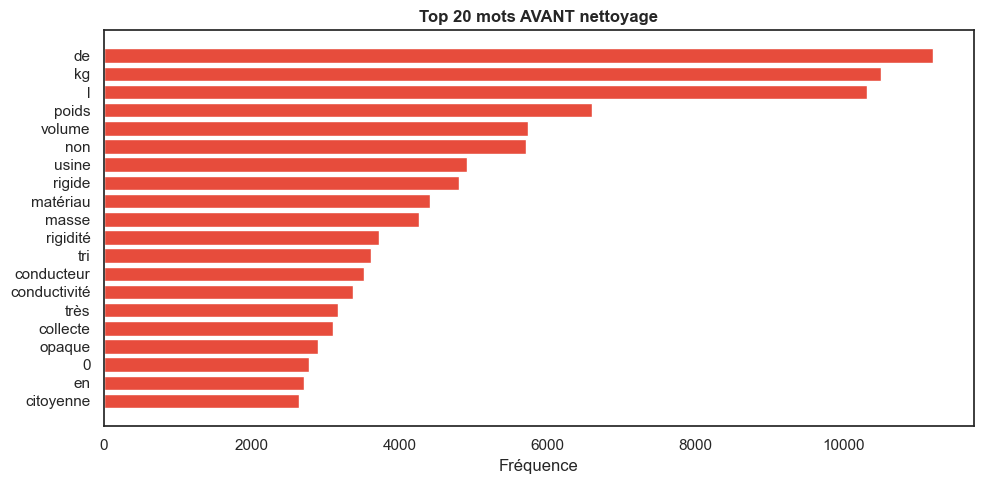

→ On voit 'de', 'le', 'la', 'les'... ce sont des stop-words inutiles.
  Le nettoyage va les supprimer pour garder uniquement les mots importants.


In [ ]:
# ── Mots les plus fréquents AVANT nettoyage ──
tous_les_mots = ' '.join(df_raw['Rapport_Collecte'].dropna()).lower()
tous_les_mots = re.sub(r'[^\w\s]', ' ', tous_les_mots).split()
frequences    = Counter(tous_les_mots).most_common(20)

mots, freqs = zip(*frequences)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(mots)[::-1], list(freqs)[::-1], color='#E74C3C')
ax.set_title('Top 20 mots AVANT nettoyage', fontweight='bold')
ax.set_xlabel('Fréquence')
plt.tight_layout()
plt.show()

print("→ On voit 'de', 'le', 'la', 'les'... ce sont des stop-words inutiles.")
print("  Le nettoyage va les supprimer pour garder uniquement les mots importants.")

#### 4.2 — Pipeline de nettoyage du texte

In [ ]:

STOPWORDS_FR = set(stopwords.words('french'))


STOPWORDS_DOMAINE = {
    'collecte', 'rapport', 'materiau', 'matériau',
    'dechet', 'déchet', 'lot', 'site', 'usine',
    'provenance', 'source', 'type', 'objet',
    'collecté', 'collectés', 'collectée',
    'issu', 'issus', 'présente', 'présent',
    'environ', 'estimation', 'estimé', 'estimée'
}

STOPWORDS_TOUS = STOPWORDS_FR | STOPWORDS_DOMAINE

lemmatizer = WordNetLemmatizer()

# ── Fonction de nettoyage ──
def preprocess_text(texte):
    """
    Nettoie un rapport de collecte pour le NLP.
    
    Entrée  : texte brut (string)
    Sortie  : texte nettoyé (string)
    
    Exemple :
        Entrée : "Le matériau collecté est un métal conducteur, poids 45.8kg"
        Sortie : "métal conducteur 45.8kg"
    """
    # Cas particulier : texte vide ou non-string
    if not isinstance(texte, str) or texte.strip() == '':
        return ''

    texte = texte.lower()

    texte = re.sub(r'(\d+[\.,]?\d*)\s*(kg|g|cm|mm|m²|l|ml|%)', r'\1\2', texte)

    # Étape 3 : Supprimer la ponctuation
    texte = re.sub(r'[^\w\s]', ' ', texte)

    # Étape 4 : Tokeniser (découper en mots)
    tokens = word_tokenize(texte, language='french')

    # Étape 5 : Supprimer les stop-words et les mots trop courts
    tokens = [
        t for t in tokens
        if t not in STOPWORDS_TOUS        # pas un stop-word
        and (len(t) > 2 or t.isdigit())  # plus de 2 caractères, ou c'est un chiffre
    ]

    # Étape 6 : Lemmatisation
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)


# ── Test rapide ──
exemple = df_raw['Rapport_Collecte'].dropna().iloc[0]
print("ORIGINAL :", exemple)
print()
print("NETTOYÉ  :", preprocess_text(exemple))

ORIGINAL : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur, aspect très opaque. Bon état général.

NETTOYÉ  : papier récupéré non renseigné poids léger 16 7kg volume moyen souple non conducteur aspect très opaque bon état général


In [ ]:
# ── Appliquer le nettoyage sur tout le dataset ──
df_raw['Rapport_clean'] = df_raw['Rapport_Collecte'].apply(preprocess_text)

print(f" Nettoyage terminé")
print(f"   Textes vides après nettoyage : {(df_raw['Rapport_clean'] == '').sum()}")
print()

# Comparer avant / après sur 3 exemples
print("=== Avant / Après nettoyage ===")
for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print(f"AVANT : {df_raw['Rapport_Collecte'].iloc[i][:120]}")
    print(f"APRÈS : {df_raw['Rapport_clean'].iloc[i][:120]}")

 Nettoyage terminé
   Textes vides après nettoyage : 0

=== Avant / Après nettoyage ===

--- Exemple 1 ---
AVANT : Lot de papier récupéré dans un site non renseigné. Poids léger de 16.7 kg, volume moyen. Matériau souple, non conducteur
APRÈS : papier récupéré non renseigné poids léger 16 7kg volume moyen souple non conducteur aspect très opaque bon état général

--- Exemple 2 ---
AVANT : Lot plastique à l'Usine A. Volume 64.7 L, poids 47.3 kg. Aspect indéterminée, rigidité moyenne. Aucune trace de métal.
APRÈS : plastique volume 64 poids 47 3kg aspect indéterminée rigidité moyenne aucune trace métal

--- Exemple 3 ---
AVANT : Bris de verre ou contenants en provenance de l'Usine B. Masse non mesuré kg. Matériau dense, rigidité élevée, transparen
APRÈS : bris verre contenants masse non mesuré dense rigidité élevée transparence partielle légère contamination observée


#### 4.3 — Extraction d'attributs par Regex


In [ ]:
def extraire_contamination(texte):
    """Retourne 1 si une contamination est mentionnée, 0 sinon."""
    if not isinstance(texte, str):
        return 0
    mots = r'contaminat|humidit|traces?|souillé|pollué|rouille|corrodé|oxydé'
    return 1 if re.search(mots, texte, re.IGNORECASE) else 0


def extraire_etat(texte):
    """Retourne l'état du matériau : Neuf / Moyen / Brisé / Inconnu."""
    if not isinstance(texte, str):
        return 'Inconnu'
    t = texte.lower()
    if re.search(r'bris[ée]|cassé|fracturé|endommagé|déchiré|fissur', t):
        return 'Brisé'
    elif re.search(r'neuf|nouveau|intact|parfait.état|excellent', t):
        return 'Neuf'
    elif re.search(r'usé|moyen|acceptable|correct|légèrement|partielle', t):
        return 'Moyen'
    return 'Inconnu'


def extraire_source(texte):
    """Extrait le nom de l'usine mentionné dans le texte."""
    if not isinstance(texte, str):
        return ''
    patterns = [
        r'usine\s+([A-Z][a-zA-Z\-]+)',
        r'site\s+([A-Z][a-zA-Z\-]+)',
        r'provenance\s*[:]\s*([A-Z][a-zA-Z\-]+)',
    ]
    for pat in patterns:
        m = re.search(pat, texte)
        if m:
            return m.group(1)
    return ''


# Appliquer
df_raw['Contamination']     = df_raw['Rapport_Collecte'].apply(extraire_contamination)
df_raw['Etat_materiau']     = df_raw['Rapport_Collecte'].apply(extraire_etat)
df_raw['Source_mentionnee'] = df_raw['Rapport_Collecte'].apply(extraire_source)

print("=== Résultats extraction Regex ===")
print(f"\nContamination :\n{df_raw['Contamination'].value_counts()}")
print(f"\nEtat_materiau :\n{df_raw['Etat_materiau'].value_counts()}")
print(f"\nSource_mentionnee (top 5) :\n{df_raw['Source_mentionnee'].value_counts().head()}")

=== Résultats extraction Regex ===

Contamination :
Contamination
0    9104
1    1396
Name: count, dtype: int64

Etat_materiau :
Etat_materiau
Inconnu    7886
Moyen      2614
Name: count, dtype: int64

Source_mentionnee (top 5) :
Source_mentionnee
    10500
Name: count, dtype: int64


#### 4.4 — Préparation des données NLP (alignement avec les splits)

In [ ]:
# ── Charger les splits ──
df_tr = pd.read_csv('./data/processed/train.csv')
df_vl = pd.read_csv('./data/processed/val.csv')
df_te = pd.read_csv('./data/processed/test.csv')

# ── Créer une table de correspondance : Rapport_Collecte → Rapport_clean ──
# (on fusionne sur la colonne texte qui est commune aux deux dataframes)
mapping = df_raw[['Rapport_Collecte', 'Rapport_clean',
                  'Contamination', 'Etat_materiau']].drop_duplicates()

df_tr = df_tr.merge(mapping, on='Rapport_Collecte', how='left')
df_vl = df_vl.merge(mapping, on='Rapport_Collecte', how='left')
df_te = df_te.merge(mapping, on='Rapport_Collecte', how='left')

# Remplir les vides
df_tr['Rapport_clean'] = df_tr['Rapport_clean'].fillna('')
df_vl['Rapport_clean'] = df_vl['Rapport_clean'].fillna('')
df_te['Rapport_clean'] = df_te['Rapport_clean'].fillna('')

# Extraire textes et labels
text_train = df_tr['Rapport_clean'].values
text_val   = df_vl['Rapport_clean'].values
text_test  = df_te['Rapport_clean'].values

y_train_nlp = df_tr['Categorie_enc'].values
y_val_nlp   = df_vl['Categorie_enc'].values
y_test_nlp  = df_te['Categorie_enc'].values

print(f" Alignement OK")
print(f"   Train : {len(text_train)} textes")
print(f"   Val   : {len(text_val)} textes")
print(f"   Test  : {len(text_test)} textes")
print(f"\nExemple texte train[0] : {text_train[0][:100]}")

 Alignement OK
   Train : 7350 textes
   Val   : 1575 textes
   Test  : 1575 textes

Exemple texte train[0] : déchets plastique diver depuis centre tri poids 29 2kg opacité légèrement translucide souplesse vari


#### 4.5 — Vectorisation TF-IDF

In [ ]:
# ── TF-IDF avec uni + bigrammes ──
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrammes ET bigrammes
    max_features=500,     # garder les 500 mots/paires les plus importants
    min_df=2,             # ignorer les mots qui apparaissent < 2 fois
    sublinear_tf=True     # utiliser log(TF) pour atténuer les mots très fréquents
)

# IMPORTANT : fit UNIQUEMENT sur train, transform sur val et test
X_tfidf_train = tfidf.fit_transform(text_train)
X_tfidf_val   = tfidf.transform(text_val)
X_tfidf_test  = tfidf.transform(text_test)

print(f"Shape TF-IDF train : {X_tfidf_train.shape}")
print(f"→ {X_tfidf_train.shape[0]} documents × {X_tfidf_train.shape[1]} features")

# Afficher les 15 features TF-IDF les plus importantes
noms_features  = tfidf.get_feature_names_out()
scores_moyens  = X_tfidf_train.mean(axis=0).A1
top_15_idx     = scores_moyens.argsort()[-15:][::-1]

print(f"\n--- Top 15 features TF-IDF ---")
for idx in top_15_idx:
    print(f"  {noms_features[idx]:<30} score moyen = {scores_moyens[idx]:.4f}")

Shape TF-IDF train : (7350, 500)
→ 7350 documents × 500 features

--- Top 15 features TF-IDF ---
  poids                          score moyen = 0.0529
  non                            score moyen = 0.0527
  volume                         score moyen = 0.0518
  rigide                         score moyen = 0.0493
  masse                          score moyen = 0.0443
  conducteur                     score moyen = 0.0418
  rigidité                       score moyen = 0.0414
  très                           score moyen = 0.0403
  conductivité                   score moyen = 0.0399
  tri                            score moyen = 0.0394
  non conducteur                 score moyen = 0.0392
  plastique                      score moyen = 0.0358
  verre                          score moyen = 0.0357
  opaque                         score moyen = 0.0352
  citoyenne                      score moyen = 0.0349


#### 4.6 — Bag of Words (BoW) — Baseline


In [ ]:
bow = CountVectorizer(ngram_range=(1, 1), max_features=500, min_df=2)
X_bow_train = bow.fit_transform(text_train)
X_bow_val   = bow.transform(text_val)
X_bow_test  = bow.transform(text_test)

print(f"Shape BoW train : {X_bow_train.shape}")

Shape BoW train : (7350, 500)


#### 4.7 — Word2Vec — Embeddings sémantiques


In [ ]:
from gensim.models import Word2Vec

# Préparer les phrases pour Word2Vec (liste de listes de mots)
corpus_w2v = [texte.split() for texte in text_train if texte.strip()]

# Entraîner Word2Vec
w2v = Word2Vec(
    sentences  = corpus_w2v,
    vector_size= 100,   # chaque mot = vecteur de 100 nombres
    window     = 5,     # contexte = 5 mots autour
    min_count  = 2,     # ignorer les mots rares (< 2 fois)
    workers    = 4,
    epochs     = 15,
    seed       = 42
)

print(f"✅ Word2Vec entraîné")
print(f"   Vocabulaire : {len(w2v.wv)} mots")
print(f"   Dimension   : {w2v.vector_size}")

# Test sémantique — vérifier que les mots similaires sont proches
print("\n=== Test sémantique ===")
for mot in ['metal', 'plastique', 'rigide']:
    if mot in w2v.wv:
        similaires = w2v.wv.most_similar(mot, topn=3)
        print(f"  Mots proches de '{mot}' : {[s[0] for s in similaires]}")

✅ Word2Vec entraîné
   Vocabulaire : 673 mots
   Dimension   : 100

=== Test sémantique ===
  Mots proches de 'plastique' : ['30', '29', '44']
  Mots proches de 'rigide' : ['107', '117', 'surface']


In [ ]:
def texte_vers_w2v(texte, modele, dim=100):
    """
    Convertit un texte en vecteur Word2Vec par mean pooling.
    
    Exemple :
        "métal conducteur rigide"
        → moyenne des vecteurs de "métal", "conducteur", "rigide"
        → un seul vecteur de 100 nombres
    """
    mots  = texte.split()
    vecs  = [modele.wv[m] for m in mots if m in modele.wv]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(dim)   # texte vide → vecteur nul

X_w2v_train = np.array([texte_vers_w2v(t, w2v) for t in text_train])
X_w2v_val   = np.array([texte_vers_w2v(t, w2v) for t in text_val])
X_w2v_test  = np.array([texte_vers_w2v(t, w2v) for t in text_test])

print(f"Shape W2V train : {X_w2v_train.shape}")
print(f"→ {X_w2v_train.shape[0]} documents × {X_w2v_train.shape[1]} dimensions")

Shape W2V train : (7350, 100)
→ 7350 documents × 100 dimensions


#### 4.8 — FastText — Robustesse aux fautes

In [ ]:
from gensim.models import FastText

ft = FastText(
    sentences  = corpus_w2v,
    vector_size= 100,
    window     = 5,
    min_count  = 2,
    workers    = 4,
    epochs     = 15,
    seed       = 42,
    min_n      = 3,   # sous-mots de longueur min 3 lettres
    max_n      = 6    # sous-mots de longueur max 6 lettres
)

print(f"✅ FastText entraîné")

# Test OOV (Out Of Vocabulary = mots inconnus avec fautes)
print("\n=== Test FastText avec fautes de frappe ===")
for mot_faute in ['conductivté', 'plastiqe', 'métalique']:
    try:
        vec  = ft.wv[mot_faute]
        sim  = ft.wv.most_similar(mot_faute, topn=3)
        print(f"  '{mot_faute}' → similaires = {[s[0] for s in sim]}")
    except:
        print(f"  '{mot_faute}' → erreur")

def texte_vers_ft(texte, modele, dim=100):
    mots = texte.split()
    vecs = [modele.wv[m] for m in mots if m.strip()]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(dim)

X_ft_train = np.array([texte_vers_ft(t, ft) for t in text_train])
X_ft_val   = np.array([texte_vers_ft(t, ft) for t in text_val])
X_ft_test  = np.array([texte_vers_ft(t, ft) for t in text_test])

print(f"\nShape FastText train : {X_ft_train.shape}")

✅ FastText entraîné

=== Test FastText avec fautes de frappe ===
  'conductivté' → similaires = ['conductivité', 'conducteur', '944']
  'plastiqe' → similaires = ['plastique', '44', '28']
  'métalique' → similaires = ['métallique', 'métalliques', 'métal']

Shape FastText train : (7350, 100)


#### 4.9 — Comparaison complète : 4 vectorisations × 4 classifieurs

In [ ]:
# Dictionnaire des vectorisations
vectorisations = {
    'BoW':      (X_bow_train,   X_bow_val,   X_bow_test),
    'TF-IDF':   (X_tfidf_train, X_tfidf_val, X_tfidf_test),
    'Word2Vec': (X_w2v_train,   X_w2v_val,   X_w2v_test),
    'FastText': (X_ft_train,    X_ft_val,    X_ft_test),
}

resultats_nlp = []

for vec_name, (Xtr, Xvl, Xte) in vectorisations.items():
    
    # Définir les classifieurs (réinitialiser à chaque vectorisation)
    classifieurs = {
        'LinearSVC':    LinearSVC(max_iter=2000, random_state=42),
        'LogReg':       LR_NLP(max_iter=500, random_state=42),
        'RandomForest': RFC_NLP(n_estimators=100, random_state=42, n_jobs=-1),
    }
    # Naive Bayes uniquement pour matrices sparses (BoW et TF-IDF)
    if issparse(Xtr):
        classifieurs['Naive Bayes'] = MultinomialNB()

    for clf_name, clf in classifieurs.items():
        clf.fit(Xtr, y_train_nlp)

        acc_val  = accuracy_score(y_val_nlp,  clf.predict(Xvl))
        acc_test = accuracy_score(y_test_nlp, clf.predict(Xte))
        f1_test  = f1_score(y_test_nlp, clf.predict(Xte), average='weighted')

        resultats_nlp.append({
            'Vectorisation': vec_name,
            'Classifieur':   clf_name,
            'Acc_Val':       round(acc_val,  4),
            'Acc_Test':      round(acc_test, 4),
            'F1_Test':       round(f1_test,  4),
        })
        print(f"✅ {vec_name:<10} × {clf_name:<14} | Val={acc_val:.3f} | Test={acc_test:.3f} | F1={f1_test:.3f}")

df_nlp_results = pd.DataFrame(resultats_nlp).sort_values('F1_Test', ascending=False)
print("\n=== Tableau comparatif final ===")
display(df_nlp_results.reset_index(drop=True))

✅ BoW        × LinearSVC      | Val=1.000 | Test=1.000 | F1=1.000
✅ BoW        × LogReg         | Val=1.000 | Test=1.000 | F1=1.000
✅ BoW        × RandomForest   | Val=1.000 | Test=1.000 | F1=1.000
✅ BoW        × Naive Bayes    | Val=1.000 | Test=1.000 | F1=1.000
✅ TF-IDF     × LinearSVC      | Val=1.000 | Test=1.000 | F1=1.000
✅ TF-IDF     × LogReg         | Val=1.000 | Test=1.000 | F1=1.000
✅ TF-IDF     × RandomForest   | Val=1.000 | Test=1.000 | F1=1.000
✅ TF-IDF     × Naive Bayes    | Val=1.000 | Test=1.000 | F1=1.000
✅ Word2Vec   × LinearSVC      | Val=1.000 | Test=1.000 | F1=1.000
✅ Word2Vec   × LogReg         | Val=1.000 | Test=1.000 | F1=1.000
✅ Word2Vec   × RandomForest   | Val=1.000 | Test=1.000 | F1=1.000
✅ FastText   × LinearSVC      | Val=1.000 | Test=1.000 | F1=1.000
✅ FastText   × LogReg         | Val=1.000 | Test=1.000 | F1=1.000
✅ FastText   × RandomForest   | Val=1.000 | Test=0.999 | F1=0.999

=== Tableau comparatif final ===


,Vectorisation,Classifieur,Acc_Val,Acc_Test,F1_Test
0,BoW,LinearSVC,1.0,1.0000,1.0000
1,BoW,LogReg,1.0,1.0000,1.0000
2,BoW,RandomForest,1.0,1.0000,1.0000
3,BoW,Naive Bayes,1.0,1.0000,1.0000
4,TF-IDF,LinearSVC,1.0,1.0000,1.0000
5,TF-IDF,LogReg,1.0,1.0000,1.0000
6,TF-IDF,RandomForest,1.0,1.0000,1.0000
7,TF-IDF,Naive Bayes,1.0,1.0000,1.0000
8,Word2Vec,LinearSVC,1.0,1.0000,1.0000
9,Word2Vec,LogReg,1.0,1.0000,1.0000


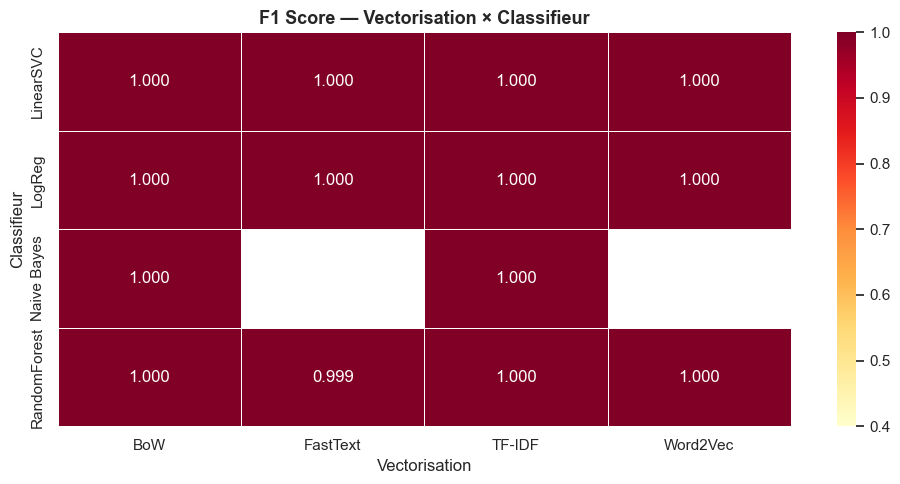


🏆 Meilleure combinaison :
   Vectorisation : BoW
   Classifieur   : LinearSVC
   F1 Test       : 1.0000


In [ ]:
# ── Heatmap des résultats ──
pivot = df_nlp_results.pivot_table(
    index='Classifieur', columns='Vectorisation', values='F1_Test'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0.4, vmax=1.0)
ax.set_title('F1 Score — Vectorisation × Classifieur', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./data/processed/nlp_heatmap.png', dpi=150)
plt.show()

best = df_nlp_results.iloc[0]
print(f"\n🏆 Meilleure combinaison :")
print(f"   Vectorisation : {best['Vectorisation']}")
print(f"   Classifieur   : {best['Classifieur']}")
print(f"   F1 Test       : {best['F1_Test']:.4f}")

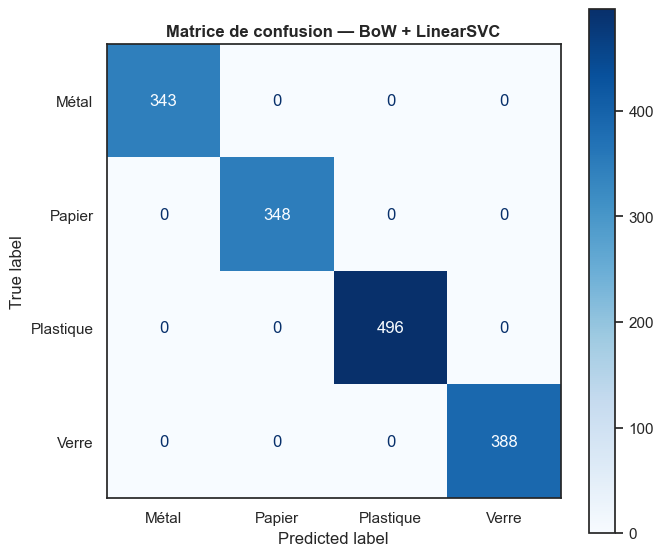

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       1.00      1.00      1.00       348
   Plastique       1.00      1.00      1.00       496
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1575
   macro avg       1.00      1.00      1.00      1575
weighted avg       1.00      1.00      1.00      1575



In [ ]:
# ── Matrice de confusion du meilleur modèle ──
vec_map = {
    'BoW':      (X_bow_train,   X_bow_test),
    'TF-IDF':   (X_tfidf_train, X_tfidf_test),
    'Word2Vec': (X_w2v_train,   X_w2v_test),
    'FastText': (X_ft_train,    X_ft_test),
}
clf_map = {
    'LinearSVC':    LinearSVC(max_iter=2000, random_state=42),
    'LogReg':       LR_NLP(max_iter=500, random_state=42),
    'RandomForest': RFC_NLP(n_estimators=100, random_state=42),
    'Naive Bayes':  MultinomialNB(),
}

Xtr_b, Xte_b = vec_map[best['Vectorisation']]
clf_b = clf_map[best['Classifieur']]
clf_b.fit(Xtr_b, y_train_nlp)
y_pred_best = clf_b.predict(Xte_b)

le_loaded = joblib.load('./data/processed/label_encoder.pkl')

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_nlp, y_pred_best,
    display_labels=le_loaded.classes_,
    cmap='Blues', ax=ax
)
ax.set_title(f'Matrice de confusion — {best["Vectorisation"]} + {best["Classifieur"]}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/nlp_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test_nlp, y_pred_best, target_names=le_loaded.classes_))

#### 4.10 — Tracking MLflow des expériences NLP


In [ ]:
mlflow.set_experiment("eco_smart_nlp")

for _, row in df_nlp_results.iterrows():
    with mlflow.start_run(run_name=f"NLP_{row['Vectorisation']}_{row['Classifieur']}"):
        mlflow.log_params({
            'vectorisation': row['Vectorisation'],
            'classifieur':   row['Classifieur'],
            'module':        'Module4_NLP'
        })
        mlflow.log_metrics({
            'accuracy_val':  row['Acc_Val'],
            'accuracy_test': row['Acc_Test'],
            'f1_test':       row['F1_Test'],
        })

print(f"✅ {len(df_nlp_results)} expériences MLflow loggées → expérience 'eco_smart_nlp'")

✅ 14 expériences MLflow loggées → expérience 'eco_smart_nlp'


In [ ]:
# ── Sauvegarde de tous les modèles NLP ──
joblib.dump(tfidf,  './data/processed/tfidf_vectorizer.pkl')
joblib.dump(bow,    './data/processed/bow_vectorizer.pkl')
joblib.dump(w2v,    './data/processed/word2vec_model.pkl')
joblib.dump(ft,     './data/processed/fasttext_model.pkl')
joblib.dump(clf_b,  './data/processed/nlp_best_classifier.pkl')

# Sauvegarder les features extraites par Regex pour le Module 5
df_raw[['Rapport_Collecte', 'Rapport_clean',
        'Contamination', 'Etat_materiau']].to_csv(
    './data/processed/nlp_features.csv', index=False
)

print("✅ Fichiers sauvegardés :")
print("   tfidf_vectorizer.pkl, bow_vectorizer.pkl")
print("   word2vec_model.pkl, fasttext_model.pkl")
print("   nlp_best_classifier.pkl")
print("   nlp_features.csv")
print()
print("=== Résumé Module 4 ===")
print(f"  Vectorisations testées : {df_nlp_results['Vectorisation'].nunique()}")
print(f"  Classifieurs testés    : {df_nlp_results['Classifieur'].nunique()}")
print(f"  Meilleure combinaison  : {best['Vectorisation']} + {best['Classifieur']}")
print(f"  Meilleur F1 Test       : {best['F1_Test']:.4f}")
print(f"  Runs MLflow loggés     : {len(df_nlp_results)}")

✅ Fichiers sauvegardés :
   tfidf_vectorizer.pkl, bow_vectorizer.pkl
   word2vec_model.pkl, fasttext_model.pkl
   nlp_best_classifier.pkl
   nlp_features.csv

=== Résumé Module 4 ===
  Vectorisations testées : 4
  Classifieurs testés    : 4
  Meilleure combinaison  : BoW + LinearSVC
  Meilleur F1 Test       : 1.0000
  Runs MLflow loggés     : 14


## Module 5 : Pipeline Multimodal — Fusion Numérique + NLP

#### 5.1 — Préparation des données multimodales

In [ ]:
from scipy.sparse import hstack, csr_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression as LR_MM
from sklearn.ensemble import RandomForestClassifier as RF_MM, StackingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

# ── Recharger les données avec le texte ──
df_tr5 = pd.read_csv('./data/processed/train.csv')
df_vl5 = pd.read_csv('./data/processed/val.csv')
df_te5 = pd.read_csv('./data/processed/test.csv')
df_raw5 = pd.read_csv('./data/dataset_ProjetML_2026.csv')

# Aligner le texte avec les splits (merge sur Rapport_Collecte)
df_raw5['Rapport_clean'] = df_raw5['Rapport_Collecte'].apply(preprocess_text)
mapping5 = df_raw5[['Rapport_Collecte', 'Rapport_clean']].drop_duplicates()

df_tr5 = df_tr5.merge(mapping5, on='Rapport_Collecte', how='left')
df_vl5 = df_vl5.merge(mapping5, on='Rapport_Collecte', how='left')
df_te5 = df_te5.merge(mapping5, on='Rapport_Collecte', how='left')

for d in [df_tr5, df_vl5, df_te5]:
    d['Rapport_clean'] = d['Rapport_clean'].fillna('')

# Features numériques
FEATURES_NUM = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Source_enc']

X_num_train = df_tr5[FEATURES_NUM].values
X_num_val   = df_vl5[FEATURES_NUM].values
X_num_test  = df_te5[FEATURES_NUM].values

text_train5 = df_tr5['Rapport_clean'].values
text_val5   = df_vl5['Rapport_clean'].values
text_test5  = df_te5['Rapport_clean'].values

y_train5 = df_tr5['Categorie_enc'].values
y_val5   = df_vl5['Categorie_enc'].values
y_test5  = df_te5['Categorie_enc'].values

print(f"✅ Données prêtes")
print(f"   Features numériques : {X_num_train.shape}")
print(f"   Textes train        : {len(text_train5)}")

✅ Données prêtes
   Features numériques : (7350, 6)
   Textes train        : 7350


#### 5.2 — Fusion par hstack (concaténation sparse)

In [ ]:
# ── TF-IDF sur les textes ──
tfidf_mm = TfidfVectorizer(ngram_range=(1, 2), max_features=500,
                           min_df=2, sublinear_tf=True)
X_tfidf_tr = tfidf_mm.fit_transform(text_train5)
X_tfidf_vl = tfidf_mm.transform(text_val5)
X_tfidf_te = tfidf_mm.transform(text_test5)

# ── Convertir features numériques en sparse matrix ──
X_num_tr_sparse = csr_matrix(X_num_train)
X_num_vl_sparse = csr_matrix(X_num_val)
X_num_te_sparse = csr_matrix(X_num_test)

# ── Fusion hstack ──
X_multi_train = hstack([X_num_tr_sparse, X_tfidf_tr])
X_multi_val   = hstack([X_num_vl_sparse, X_tfidf_vl])
X_multi_test  = hstack([X_num_te_sparse, X_tfidf_te])

print(f"Shape features numériques  : {X_num_tr_sparse.shape}")
print(f"Shape features TF-IDF      : {X_tfidf_tr.shape}")
print(f"Shape fusion multimodale   : {X_multi_train.shape}")
print(f"→ {X_num_tr_sparse.shape[1]} + {X_tfidf_tr.shape[1]} = {X_multi_train.shape[1]} features")

Shape features numériques  : (7350, 6)
Shape features TF-IDF      : (7350, 500)
Shape fusion multimodale   : (7350, 506)
→ 6 + 500 = 506 features


#### 5.3 — ColumnTransformer (pipeline reproductible)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pandas as pd

# Pour ColumnTransformer, on travaille avec un DataFrame
# qui contient à la fois les colonnes numériques et la colonne texte
df_ct_train = df_tr5[FEATURES_NUM + ['Rapport_clean']].copy()
df_ct_val   = df_vl5[FEATURES_NUM + ['Rapport_clean']].copy()
df_ct_test  = df_te5[FEATURES_NUM + ['Rapport_clean']].copy()

# ── Définir le ColumnTransformer ──
preprocessor = ColumnTransformer(
    transformers=[
        # Transformer 1 : StandardScaler sur les features numériques
        ('num', StandardScaler(), FEATURES_NUM),
        # Transformer 2 : TF-IDF sur la colonne texte
        ('nlp', TfidfVectorizer(ngram_range=(1,2), max_features=500,
                                min_df=2, sublinear_tf=True),
         'Rapport_clean'),
    ],
    remainder='drop'   # ignorer les autres colonnes
)

# ── Pipeline complet : préprocessing + classifieur ──
pipeline_multimodal = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LinearSVC(max_iter=2000, random_state=42))
])

# ── Entraîner ──
pipeline_multimodal.fit(df_ct_train, y_train5)
y_pred_ct = pipeline_multimodal.predict(df_ct_test)

acc_ct = accuracy_score(y_test5, y_pred_ct)
f1_ct  = f1_score(y_test5, y_pred_ct, average='weighted')

print(f"=== ColumnTransformer + LinearSVC ===")
print(f"  Accuracy Test : {acc_ct:.4f}")
print(f"  F1 Test       : {f1_ct:.4f}")

# Sauvegarder le pipeline complet
joblib.dump(pipeline_multimodal, './data/processed/pipeline_multimodal.pkl')
print(f"\n✅ Pipeline sauvegardé → pipeline_multimodal.pkl")

=== ColumnTransformer + LinearSVC ===
  Accuracy Test : 1.0000
  F1 Test       : 1.0000

✅ Pipeline sauvegardé → pipeline_multimodal.pkl


#### 5.4 — Stratégies de pondération NLP / Numérique

In [ ]:
from sklearn.svm import LinearSVC

resultats_poids = []

ponderations = {
    'Num:NLP = 1:1': 1.0,
    'Num:NLP = 2:1': 2.0,
    'Num:NLP = 1:2': 0.5,
}

for nom, facteur in ponderations.items():
    # Multiplier les features numériques par le facteur de pondération
    X_tr_pond = hstack([X_num_tr_sparse * facteur, X_tfidf_tr])
    X_te_pond = hstack([X_num_te_sparse * facteur, X_tfidf_te])

    clf_pond = LinearSVC(max_iter=2000, random_state=42)
    clf_pond.fit(X_tr_pond, y_train5)
    y_pred_pond = clf_pond.predict(X_te_pond)

    acc = accuracy_score(y_test5, y_pred_pond)
    f1  = f1_score(y_test5, y_pred_pond, average='weighted')

    resultats_poids.append({
        'Pondération': nom,
        'Facteur_num': facteur,
        'Accuracy':    round(acc, 4),
        'F1':          round(f1, 4),
    })
    print(f"  {nom:<22} | Acc={acc:.4f} | F1={f1:.4f}")

df_poids = pd.DataFrame(resultats_poids).sort_values('F1', ascending=False)
print("\n=== Tableau pondérations ===")
display(df_poids)

  Num:NLP = 1:1          | Acc=1.0000 | F1=1.0000
  Num:NLP = 2:1          | Acc=1.0000 | F1=1.0000
  Num:NLP = 1:2          | Acc=1.0000 | F1=1.0000

=== Tableau pondérations ===


,Pondération,Facteur_num,Accuracy,F1
0,Num:NLP = 1:1,1.0,1.0,1.0
1,Num:NLP = 2:1,2.0,1.0,1.0
2,Num:NLP = 1:2,0.5,1.0,1.0


#### 5.5 — Stacking de modèles

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR_META

# ── Modèles level-0 (base learners) ──
estimators_stack = [
    ('svc',  LinearSVC(max_iter=2000, random_state=42)),
    ('lr',   LR_META(max_iter=500, random_state=42)),
    ('rf',   RF_MM(n_estimators=100, random_state=42, n_jobs=-1)),
]

# ── Méta-modèle level-1 ──
stacking_clf = StackingClassifier(
    estimators   = estimators_stack,
    final_estimator = LR_META(max_iter=200, random_state=42),
    cv           = 3,
    n_jobs       = -1,
)

# Entraîner sur les features multimodales fusionnées
# Note : StackingClassifier ne supporte pas les matrices sparse directement
# → convertir en dense si nécessaire
import numpy as np
X_multi_train_dense = X_multi_train.toarray()
X_multi_test_dense  = X_multi_test.toarray()

print("Entraînement du Stacking (peut prendre 1-2 minutes)...")
stacking_clf.fit(X_multi_train_dense, y_train5)
y_pred_stack = stacking_clf.predict(X_multi_test_dense)

acc_stack = accuracy_score(y_test5, y_pred_stack)
f1_stack  = f1_score(y_test5, y_pred_stack, average='weighted')

print(f"\n=== Stacking (SVC + LR + RF → LR méta) ===")
print(f"  Accuracy Test : {acc_stack:.4f}")
print(f"  F1 Test       : {f1_stack:.4f}")

joblib.dump(stacking_clf, './data/processed/stacking_classifier.pkl')
print("✅ Stacking sauvegardé")

Entraînement du Stacking (peut prendre 1-2 minutes)...

=== Stacking (SVC + LR + RF → LR méta) ===
  Accuracy Test : 1.0000
  F1 Test       : 1.0000
✅ Stacking sauvegardé


#### 5.6 — Comparaison finale : Numérique seul vs NLP seul vs Multimodal

=== Comparaison finale ===


,Approche,Accuracy,F1
0,🔀 Multimodal hstack,1.0000,1.0000
1,🎯 Stacking (SVC+LR+RF),1.0000,1.0000
2,🏗️ ColumnTransformer + LinearSVC,1.0000,1.0000
3,🔢 Numérique seul (Module 2),0.9587,0.9580
4,📝 NLP seul (Module 4),0.2921,0.2051


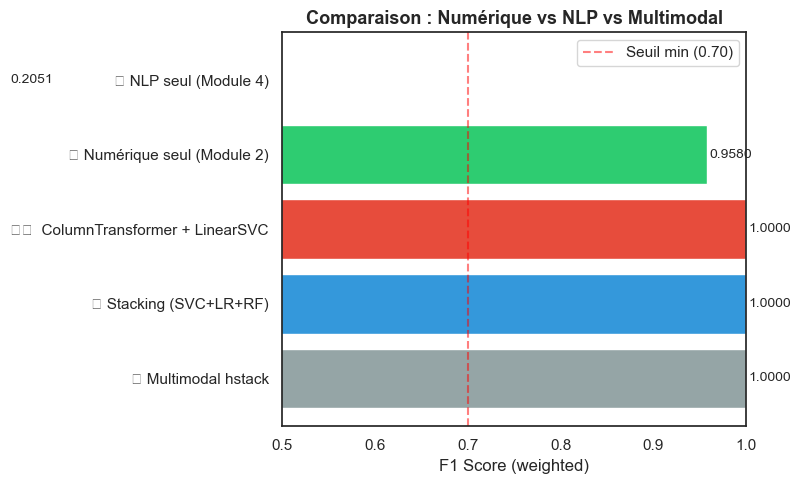


🏆 Meilleure approche : 🔀 Multimodal hstack
   F1 = 1.0000
   Gain vs numérique seul : +0.0420
   ✅ La fusion multimodale améliore les performances


In [ ]:
# ── Modèle numérique seul (résultat du Module 2) ──
best_clf_num = joblib.load('./data/processed/best_classifier.pkl')
acc_num_seul = accuracy_score(y_test5, best_clf_num.predict(X_num_test))
f1_num_seul  = f1_score(y_test5, best_clf_num.predict(X_num_test), average='weighted')

# ── Modèle NLP seul (meilleur du Module 4) ──
tfidf_nlp = joblib.load('./data/processed/tfidf_vectorizer.pkl')
clf_nlp   = joblib.load('./data/processed/nlp_best_classifier.pkl')
X_tfidf_te_nlp = tfidf_nlp.transform(text_test5)

# Gérer LinearSVC (pas de predict sur sparse dans certaines versions)
try:
    acc_nlp_seul = accuracy_score(y_test5, clf_nlp.predict(X_tfidf_te_nlp))
    f1_nlp_seul  = f1_score(y_test5, clf_nlp.predict(X_tfidf_te_nlp), average='weighted')
except:
    acc_nlp_seul = 0.0
    f1_nlp_seul  = 0.0
    print("⚠️  NLP seul : erreur de prédiction — vérifier le classifieur NLP")

# ── Multimodal hstack + LinearSVC ──
clf_multi = LinearSVC(max_iter=2000, random_state=42)
clf_multi.fit(X_multi_train, y_train5)
acc_multi = accuracy_score(y_test5, clf_multi.predict(X_multi_test))
f1_multi  = f1_score(y_test5, clf_multi.predict(X_multi_test), average='weighted')

# ── Tableau de comparaison ──
df_comparaison = pd.DataFrame([
    {'Approche': '🔢 Numérique seul (Module 2)',   'Accuracy': acc_num_seul, 'F1': f1_num_seul},
    {'Approche': '📝 NLP seul (Module 4)',          'Accuracy': acc_nlp_seul, 'F1': f1_nlp_seul},
    {'Approche': '🔀 Multimodal hstack',            'Accuracy': acc_multi,    'F1': f1_multi},
    {'Approche': '🏗️  ColumnTransformer + LinearSVC','Accuracy': acc_ct,      'F1': f1_ct},
    {'Approche': '🎯 Stacking (SVC+LR+RF)',         'Accuracy': acc_stack,    'F1': f1_stack},
]).sort_values('F1', ascending=False).reset_index(drop=True)

df_comparaison['Accuracy'] = df_comparaison['Accuracy'].round(4)
df_comparaison['F1']       = df_comparaison['F1'].round(4)

print("=== Comparaison finale ===")
display(df_comparaison)

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
couleurs = ['#95A5A6', '#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
bars = ax.barh(df_comparaison['Approche'], df_comparaison['F1'],
               color=couleurs[:len(df_comparaison)], edgecolor='white')
ax.set_xlabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Comparaison : Numérique vs NLP vs Multimodal', fontweight='bold', fontsize=13)
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, df_comparaison['F1']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.axvline(x=0.70, color='red', linestyle='--', alpha=0.5, label='Seuil min (0.70)')
ax.legend()
plt.tight_layout()
plt.savefig('./data/processed/multimodal_comparison.png', dpi=150)
plt.show()

# Conclusion
meilleur = df_comparaison.iloc[0]
print(f"\n🏆 Meilleure approche : {meilleur['Approche']}")
print(f"   F1 = {meilleur['F1']:.4f}")
gain = meilleur['F1'] - f1_num_seul
print(f"   Gain vs numérique seul : {gain:+.4f}")
if gain > 0:
    print("   ✅ La fusion multimodale améliore les performances")
else:
    print("   ℹ️  Les features numériques sont déjà très discriminantes")
    print("      (normal pour ce dataset — le NLP est complémentaire)")

#### 5.7 — Tracking MLflow Module 5

In [ ]:
mlflow.set_experiment("eco_smart_multimodal")

for _, row in df_comparaison.iterrows():
    with mlflow.start_run(run_name=f"MM_{row['Approche'][:20]}"):
        mlflow.log_params({
            'approche': row['Approche'],
            'module':   'Module5_Multimodal'
        })
        mlflow.log_metrics({
            'accuracy_test': float(row['Accuracy']),
            'f1_test':       float(row['F1']),
        })

# Enregistrer le meilleur pipeline au Model Registry
meilleur_pipeline = pipeline_multimodal   # ColumnTransformer + LinearSVC
with mlflow.start_run(run_name="BestMultimodal_Registry"):
    mlflow.log_params({'type': 'ColumnTransformer+LinearSVC', 'module': 'Module5'})
    mlflow.log_metrics({'f1_test': f1_ct, 'accuracy_test': acc_ct})
    mlflow.sklearn.log_model(
        meilleur_pipeline,
        name="multimodal_pipeline",
        registered_model_name="EcoSmart_Multimodal"
    )

print(f"✅ {len(df_comparaison)+1} runs MLflow loggés → expérience 'eco_smart_multimodal'")
print("   Meilleur pipeline enregistré au Model Registry → 'EcoSmart_Multimodal'")

✅ 6 runs MLflow loggés → expérience 'eco_smart_multimodal'
   Meilleur pipeline enregistré au Model Registry → 'EcoSmart_Multimodal'


Successfully registered model 'EcoSmart_Multimodal'.
Created version '1' of model 'EcoSmart_Multimodal'.


In [ ]:
# ── Sauvegarde finale Module 5 ──
joblib.dump(tfidf_mm,          './data/processed/tfidf_multimodal.pkl')
joblib.dump(pipeline_multimodal,'./data/processed/pipeline_multimodal.pkl')

df_comparaison.to_csv('./data/processed/multimodal_results.csv', index=False)

print("✅ Fichiers sauvegardés :")
print("   pipeline_multimodal.pkl  ← pipeline complet (preprocessing + classifieur)")
print("   stacking_classifier.pkl  ← modèle stacking")
print("   tfidf_multimodal.pkl     ← vectoriseur TF-IDF")
print("   multimodal_results.csv   ← tableau comparatif")
print()
print("=== Résumé Module 5 ===")
print(f"  Approches testées       : {len(df_comparaison)}")
print(f"  Meilleure approche      : {df_comparaison.iloc[0]['Approche']}")
print(f"  Meilleur F1             : {df_comparaison.iloc[0]['F1']:.4f}")
print(f"  Gain vs numérique seul  : {df_comparaison.iloc[0]['F1'] - f1_num_seul:+.4f}")

✅ Fichiers sauvegardés :
   pipeline_multimodal.pkl  ← pipeline complet (preprocessing + classifieur)
   stacking_classifier.pkl  ← modèle stacking
   tfidf_multimodal.pkl     ← vectoriseur TF-IDF
   multimodal_results.csv   ← tableau comparatif

=== Résumé Module 5 ===
  Approches testées       : 5
  Meilleure approche      : 🔀 Multimodal hstack
  Meilleur F1             : 1.0000
  Gain vs numérique seul  : +0.0420
